#### 1.2.1 Bag of Words
1. Tokenization: 문장을 개별 단어나 subword(token)으로 분활하는 과정
   - 여러 방법이 있지만, 공백을 기준으로 개별단어를 분할하는 방법이 널리 쓰임
   - 
2. Make Vocabuluary: token의 집합
   
vocabulary를 사용하여 각 단어가 얼마나 등장하는지 헤아림. 
아래 그림과 같이 벡터 또는 벡터 표현이라 부르는 수치의 형태로 텍스트를 표현하는 것이 목표임. 이런 모델을 represenation model이라고 부름
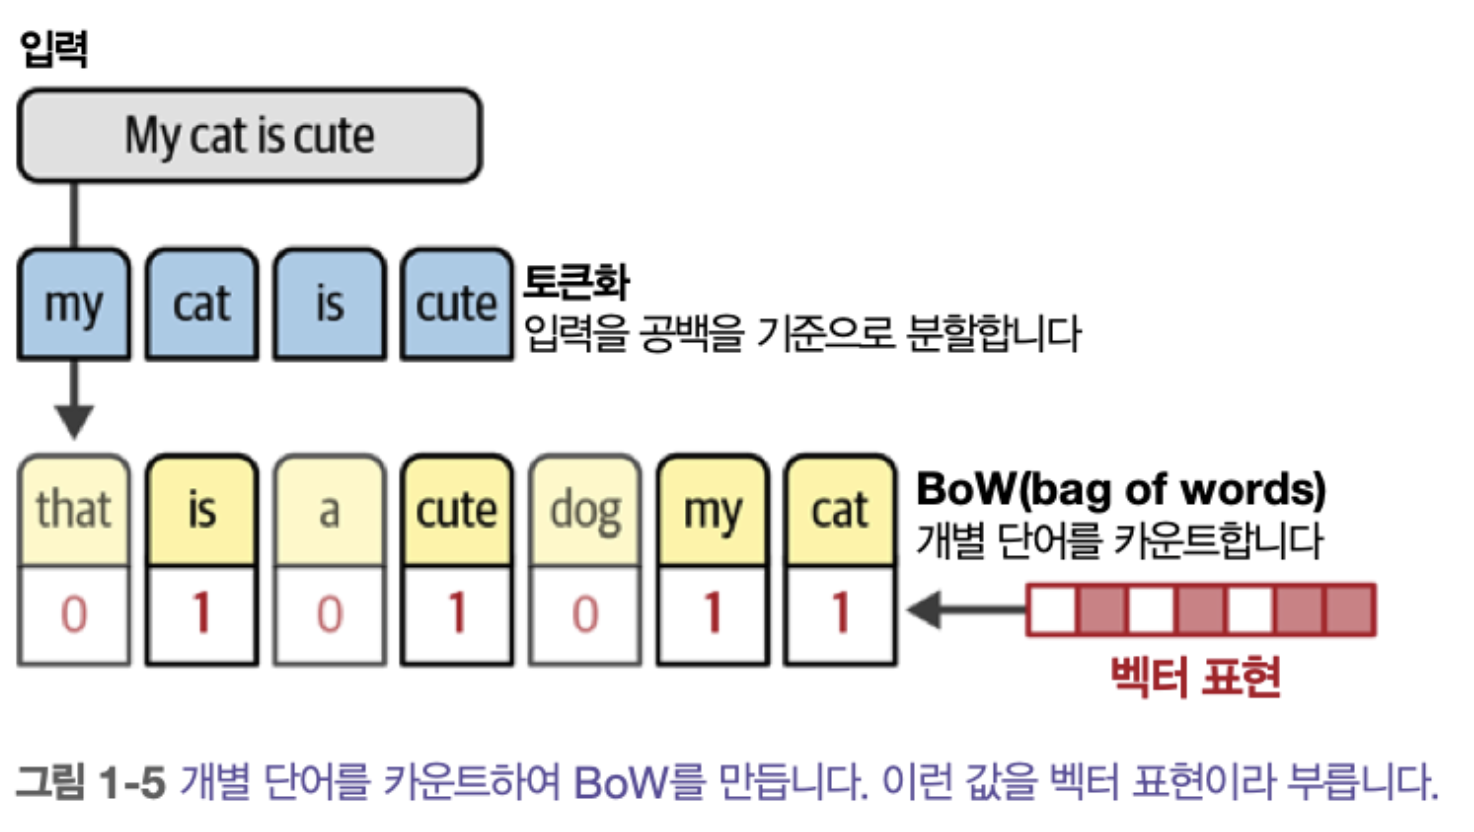

#### 1.2.2 밀집벡터 임베딩으로 더 나은 표햔 만들기
- BoW의 접근 방식은 언어를 글자 그대로 가방에 담긴 단어의 모음 이상으로 생각하지 않으며 텍스트의 본질과 의미를 무시함. 
- word2vec은 embedding으로 텍스트의 의미를 포착하는데 성공한 첫 번째 시도임.   
  https://arxiv.org/pdf/1301.378z
  - Embedding: 데이터의 의미를 포착하기 위한 벡터 표현
- Neural Network을 사용해 의미 표현을 생성함. 주어진 문장에서 다음에 어떤 단어가 등장하는지를 살펴봄으로써 단어 embedding을 생성함
  1. vocabulry에 있는 모든 단어에 대해서 랜덤하게 초기화된 일련의 값을 단어 임베딩으로 할당: https://www.kaggle.com/datasets/sugataghosh/google-word2vec
  2. 훈련 스텝마다 훈련 데이터에서 단어 쌍을 가져와서 모델이 문장 안에서 단어 쌍이 이웃에 나타날 가능성이 있는지 예측하게 함: 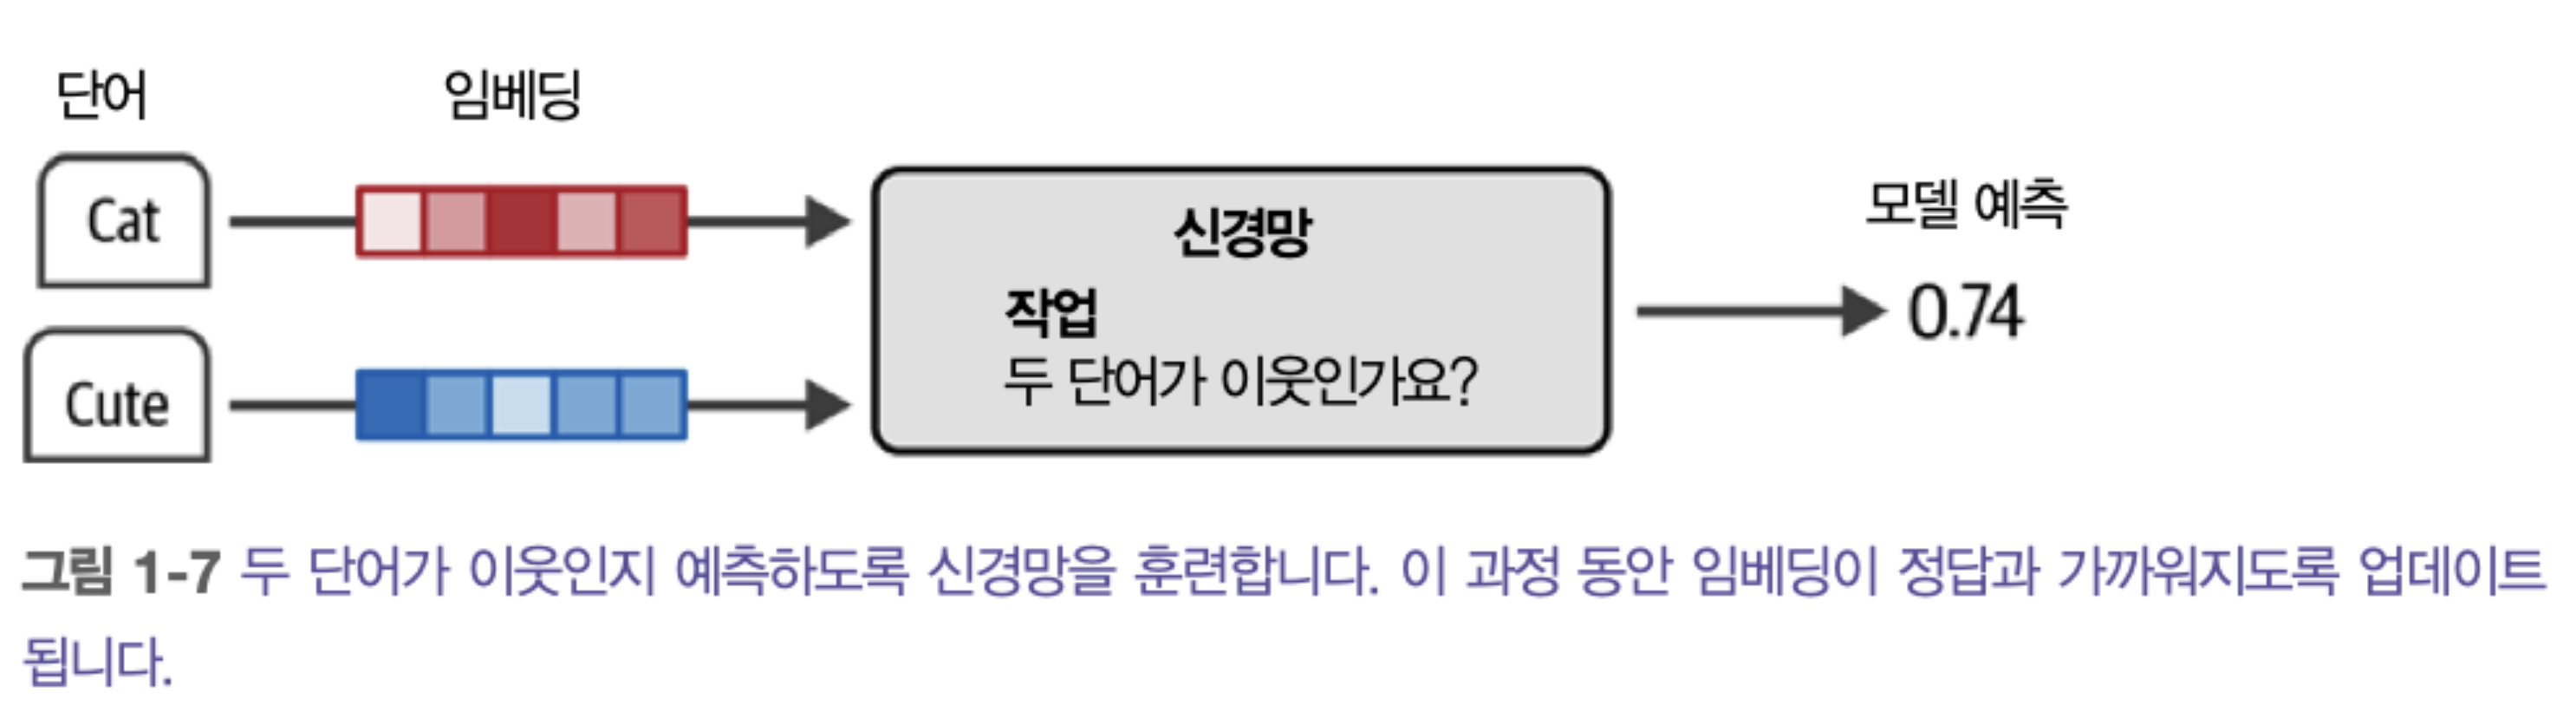
    - 이러한 embedding은 단어의 의미를 포착함. 
    - embedding은 단어의 의미를 표현하기 위해 여러 속성을 가짐. 이는 mental representation을 만들도록 선택됨. 
        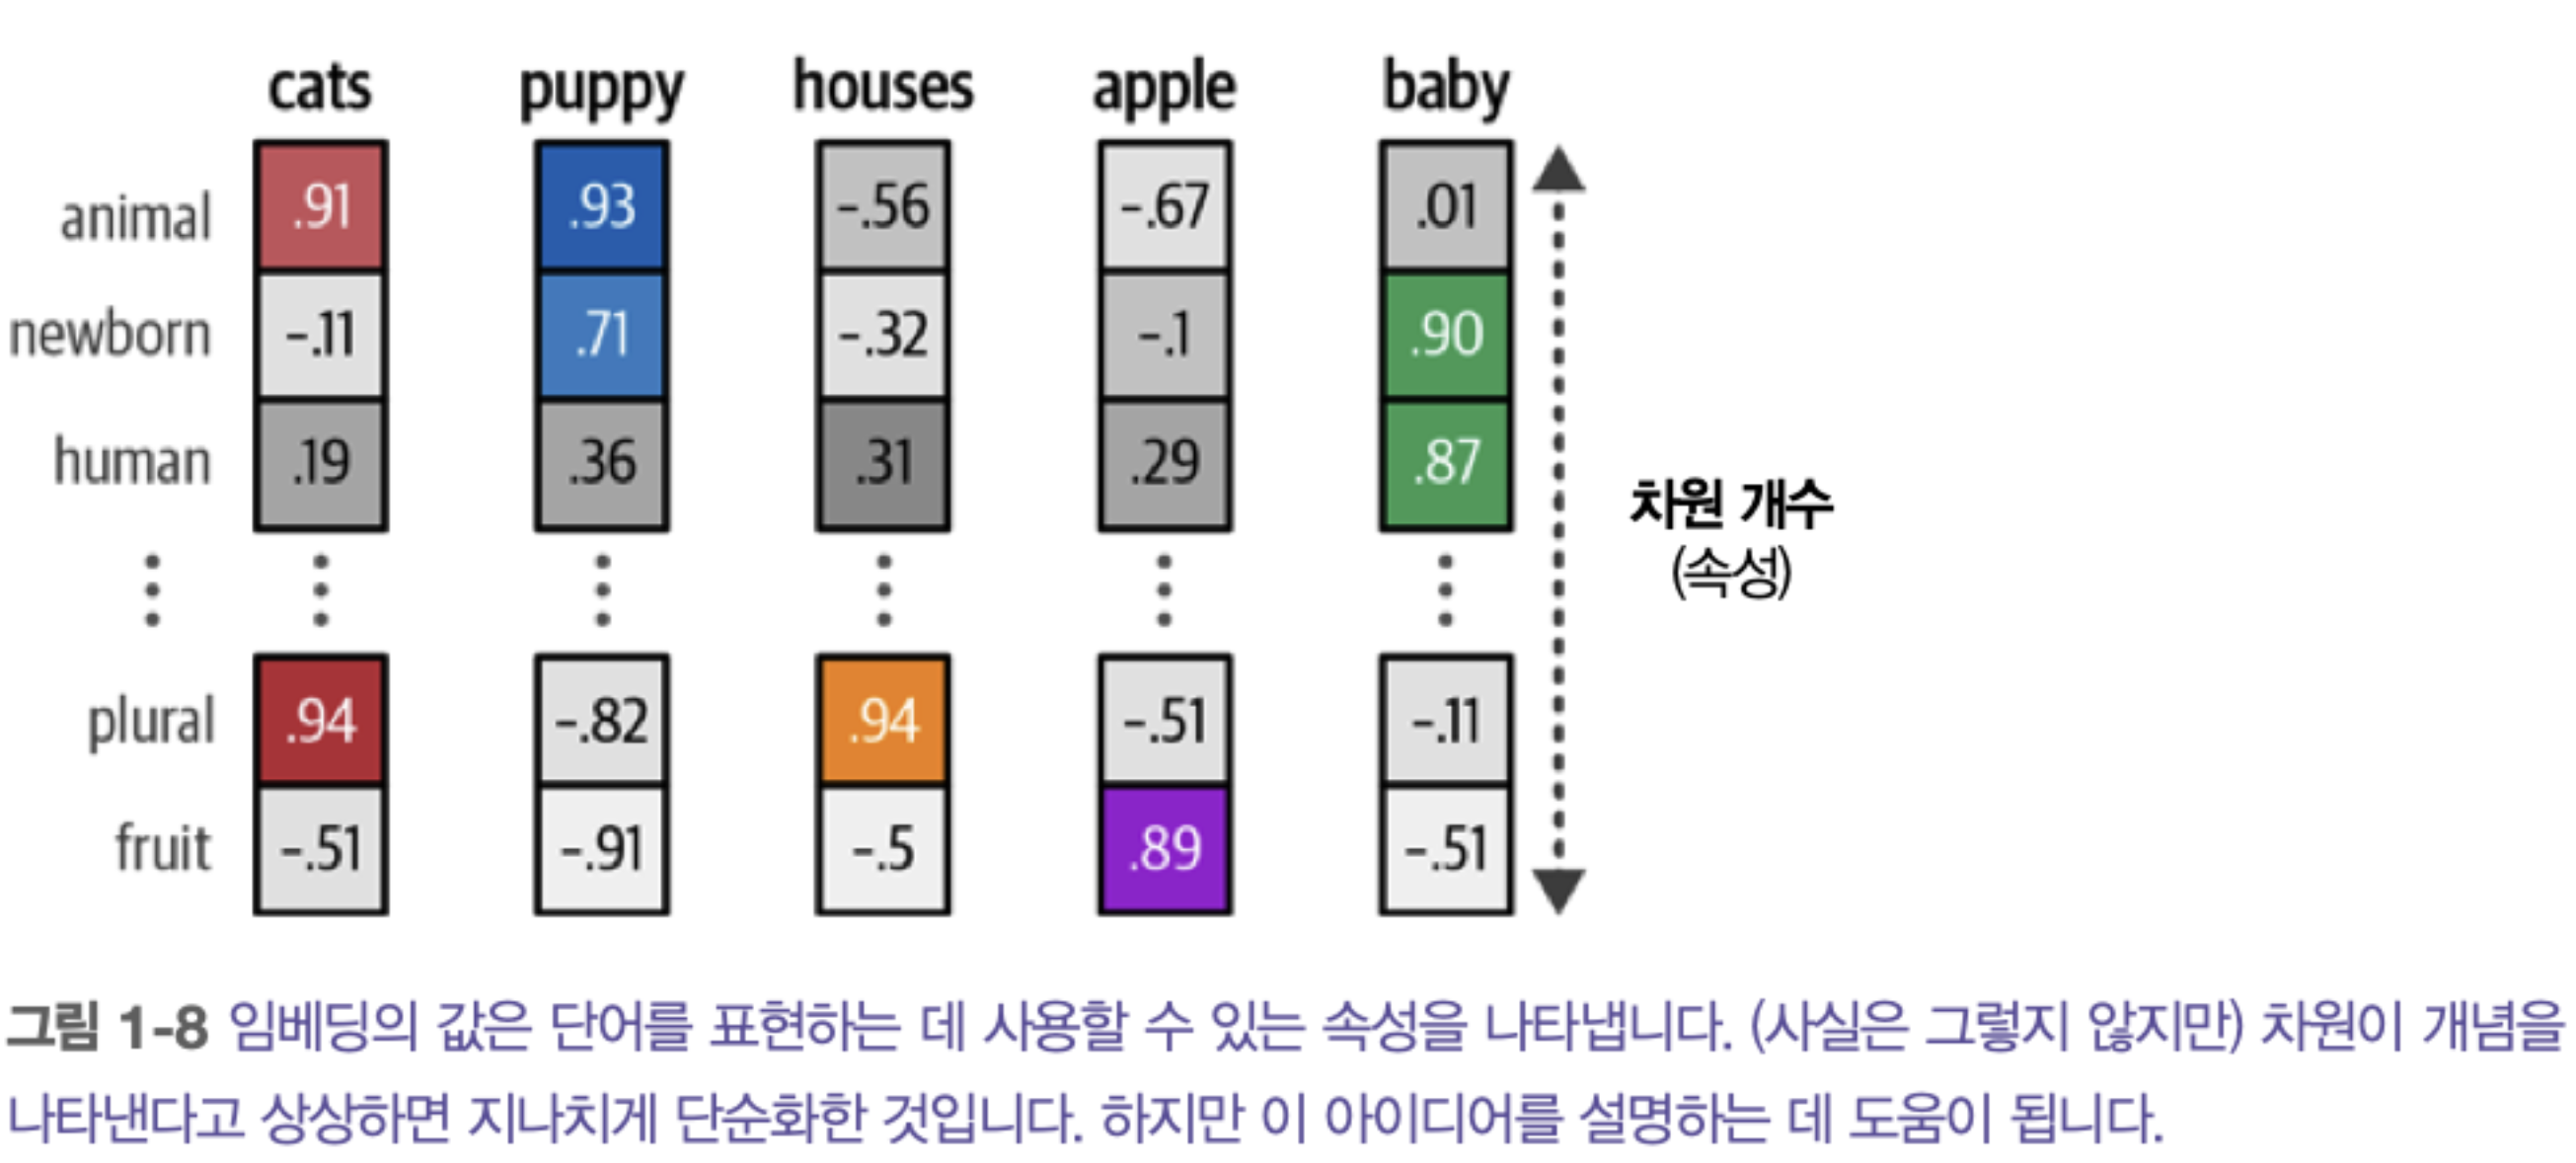
        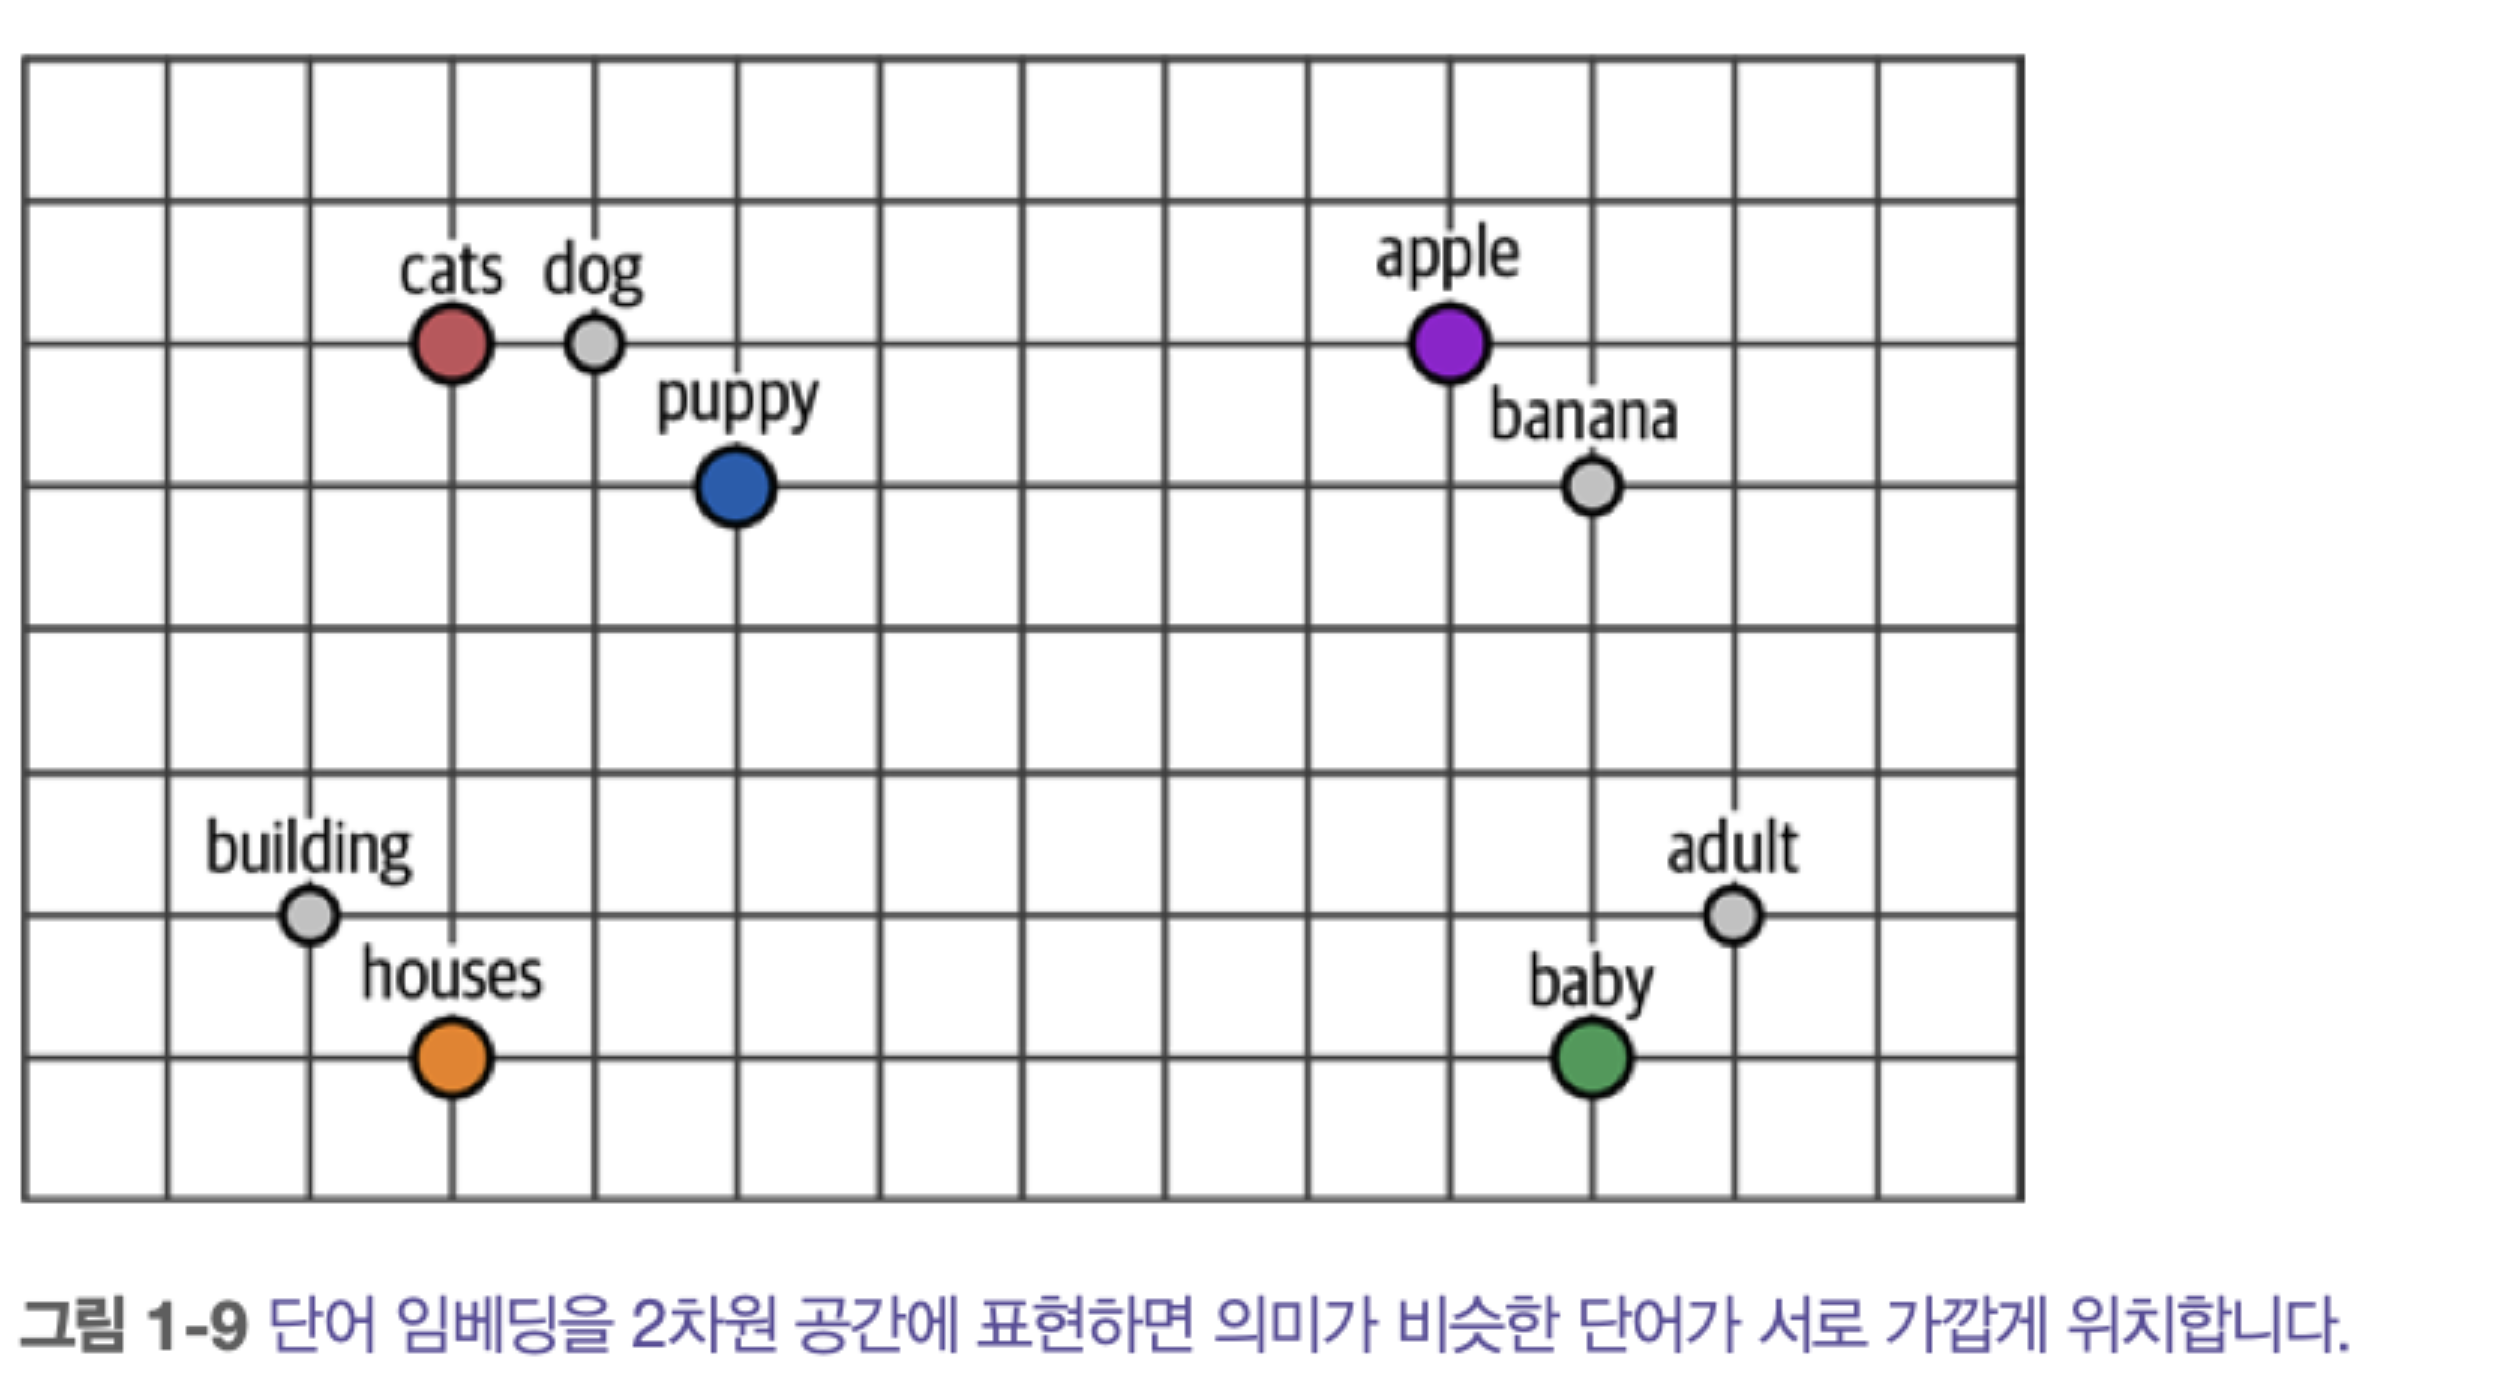

#### 1.2.3 임베딩의 종류
- 단어 임베딩과 문장 임베딩은 다른 수준(단어 vs 문장)의 추상화에 사용됨
- BoW: 전체 문서를 표현하므로 문서 수준에서 임베딩을 만듦
- word2vec: 단어에 대한 임베딩만 생성
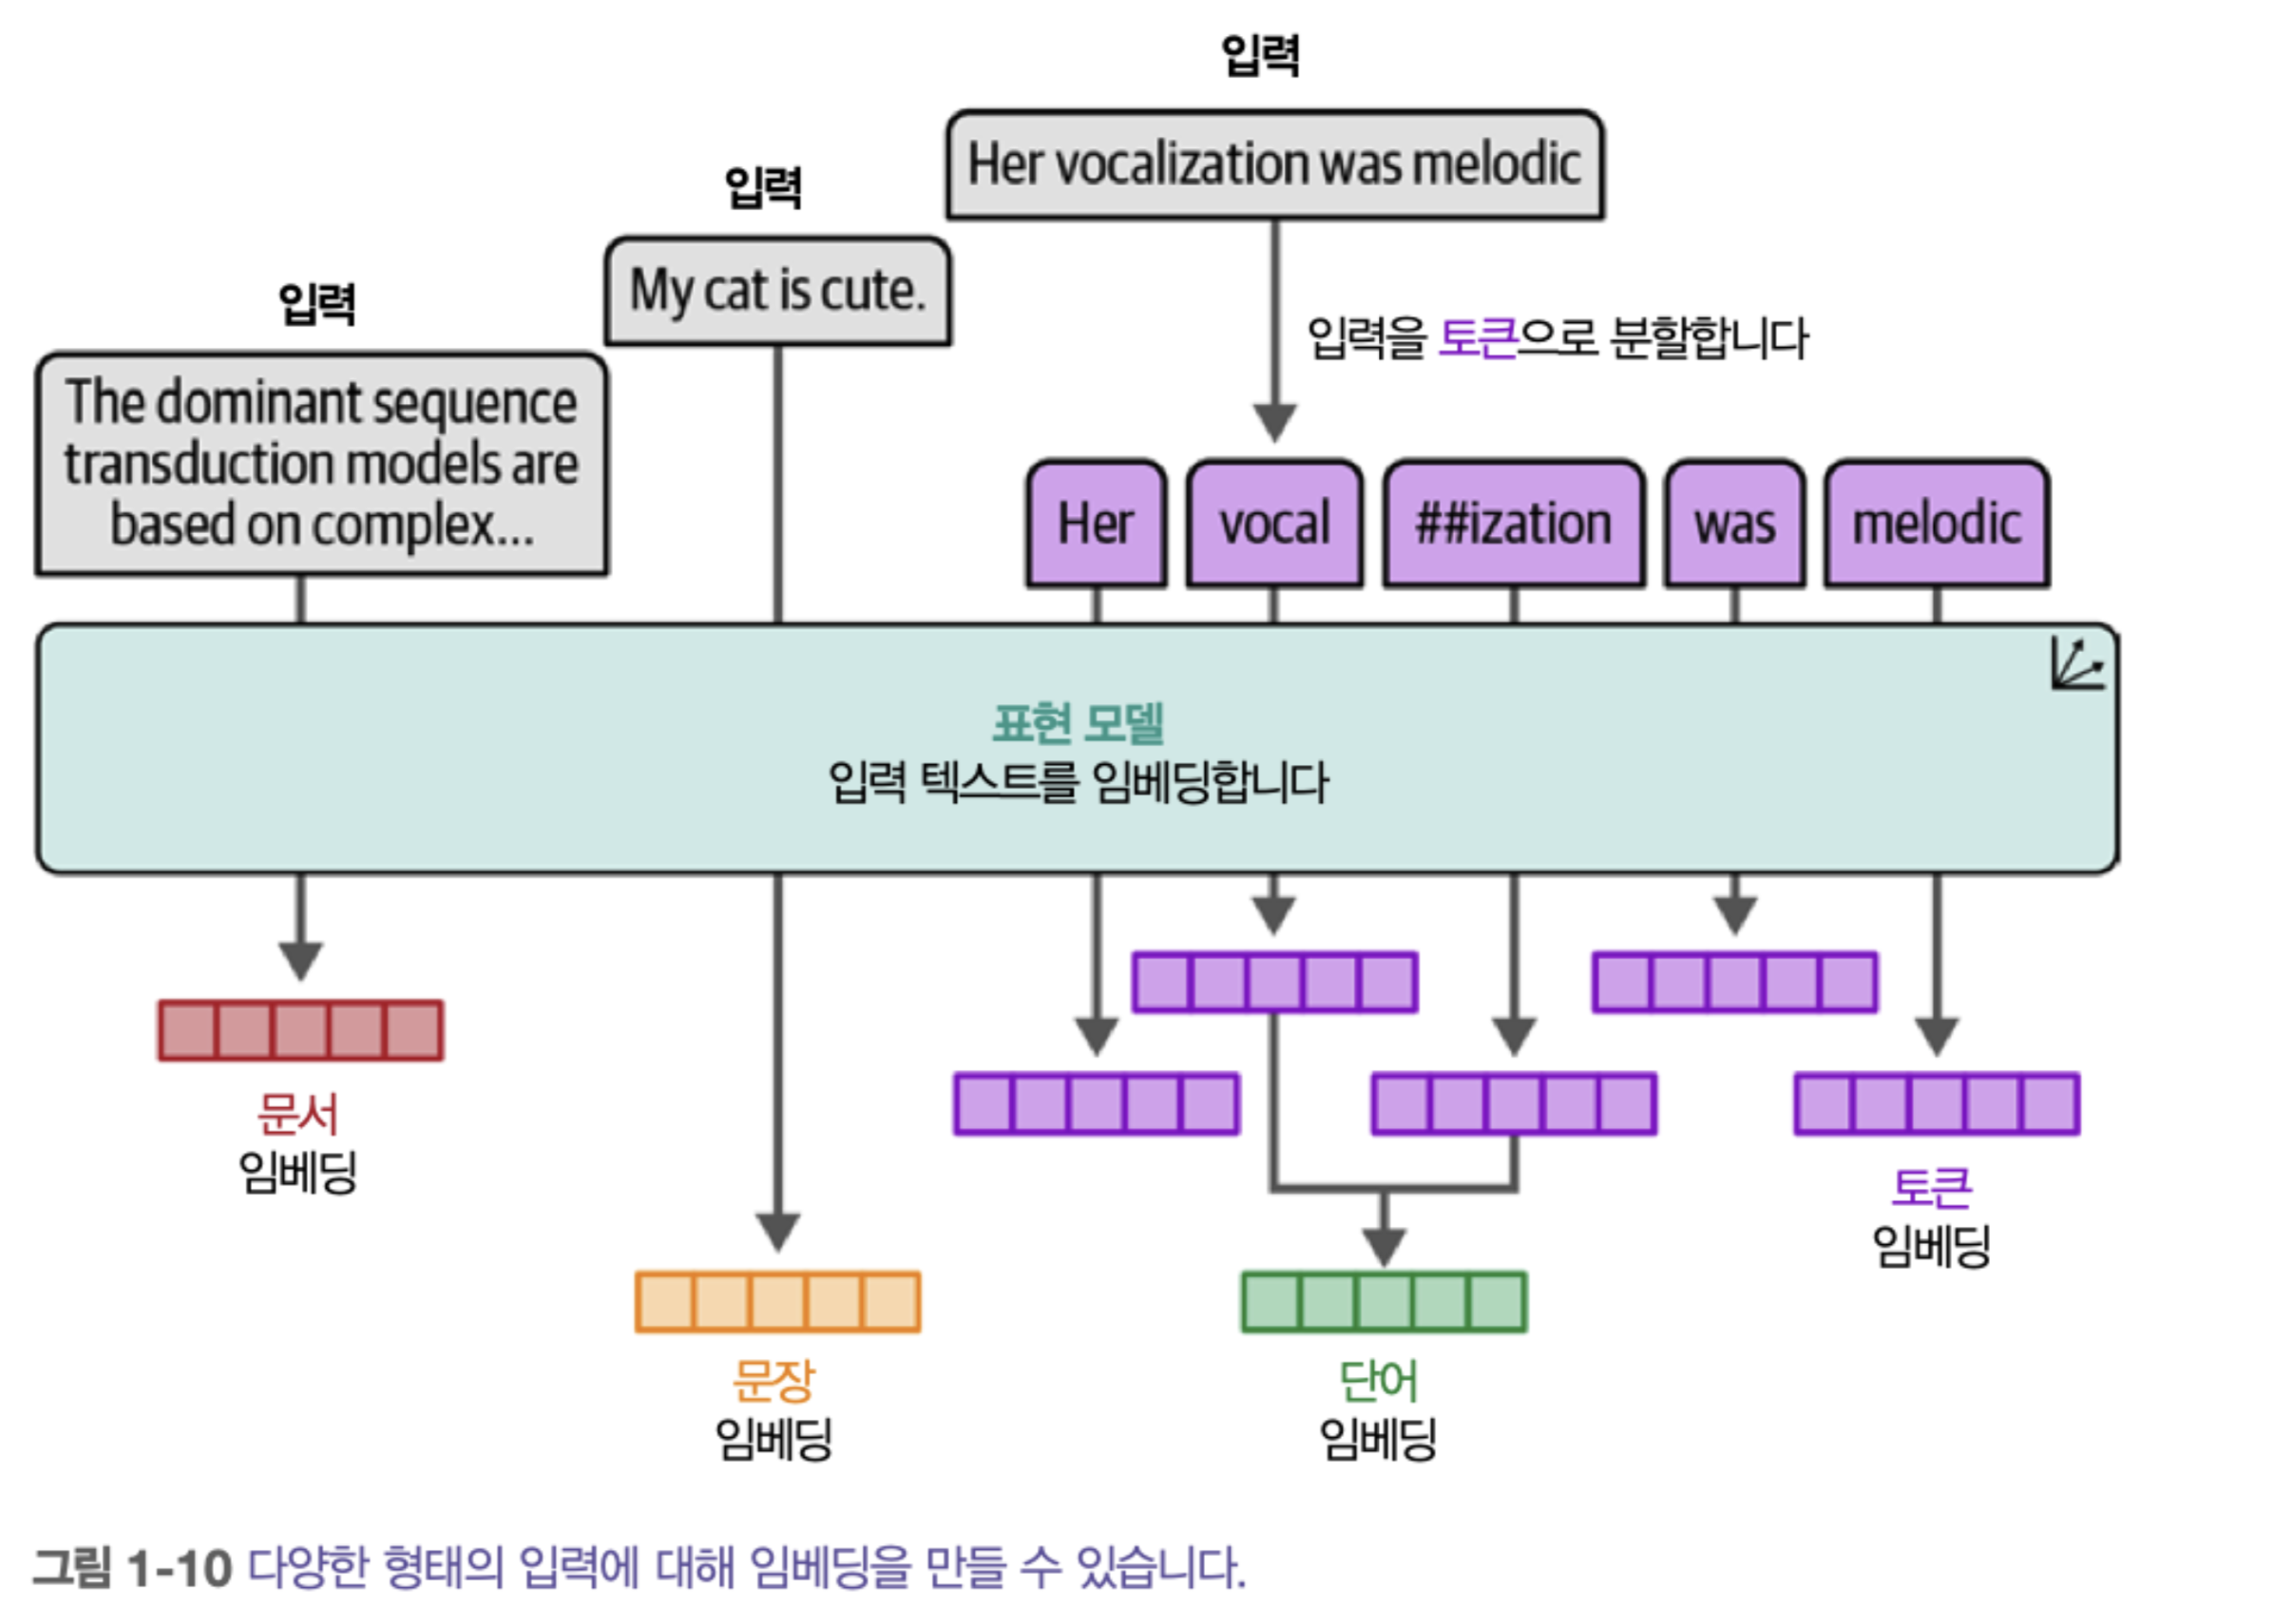

#### 1.2.4 어텐션을 사용한 문맥 인코딩과 디코딩
- word2vec: 훈련과정은 static, 다운로드 가능한 언어 표현만 만듦(e.g. bank는 문맥에 상관없이 항상 동일한 임베딩)
- 하지만 문맥에 따라 임베딩이 달라져야한다. 이런 텍스트를 인코딩하는 단계는 RNN으로 달성되었음. RNN은 연속적인 입력으로 sequence를 모델링할 수 있는 신경망의 한 종류임. 
- RNN은 두 개의 작업에 사용: 
    1. 입력 문장을 encoding 또는 표현
    2. 출력 문장을 decoding 또는 생성
   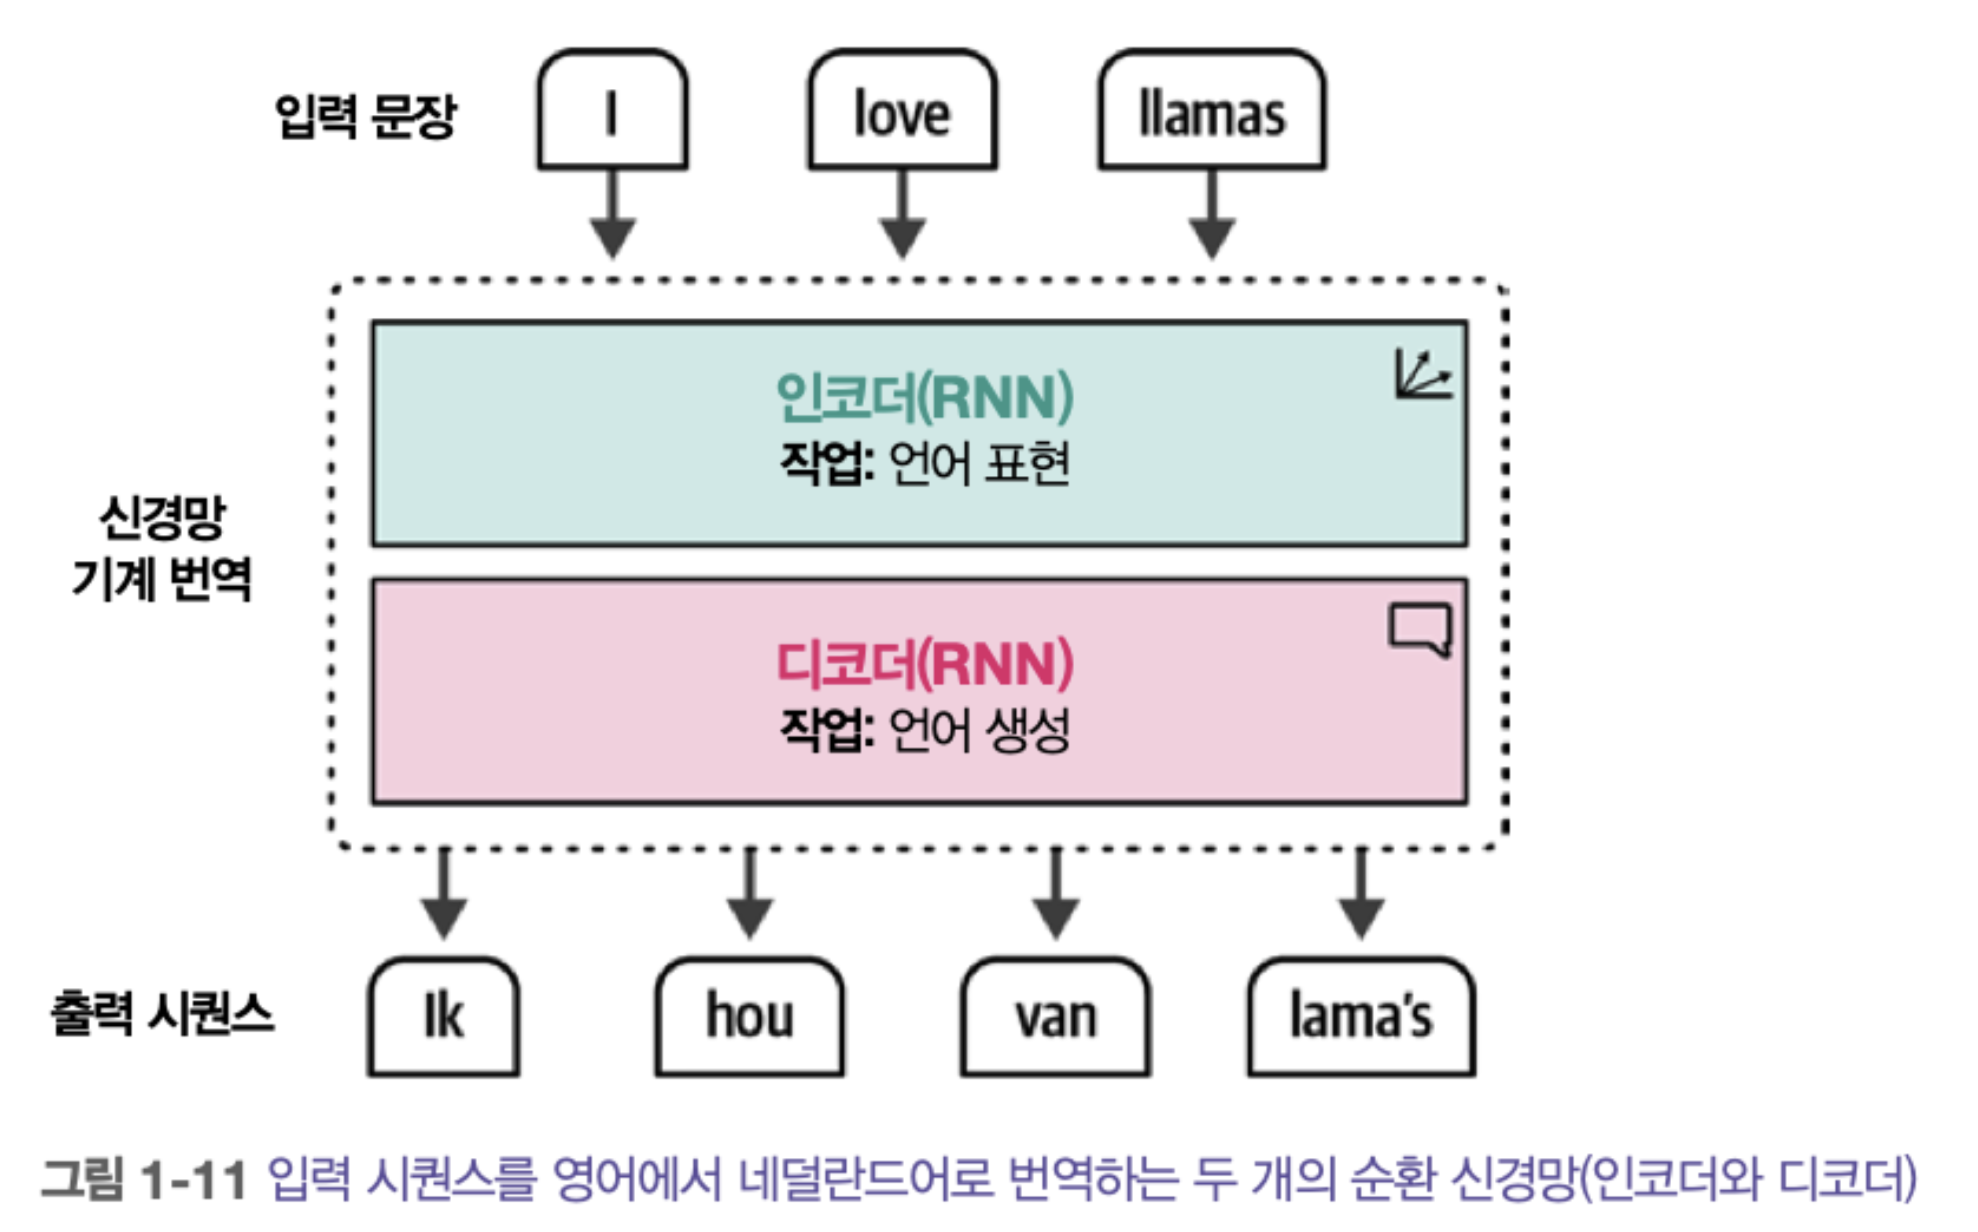

- 이 구조에서 각 단계는 autoregressive이다. 이전에 생성한 모든 단어를 사용해 다음 단어를 생성
  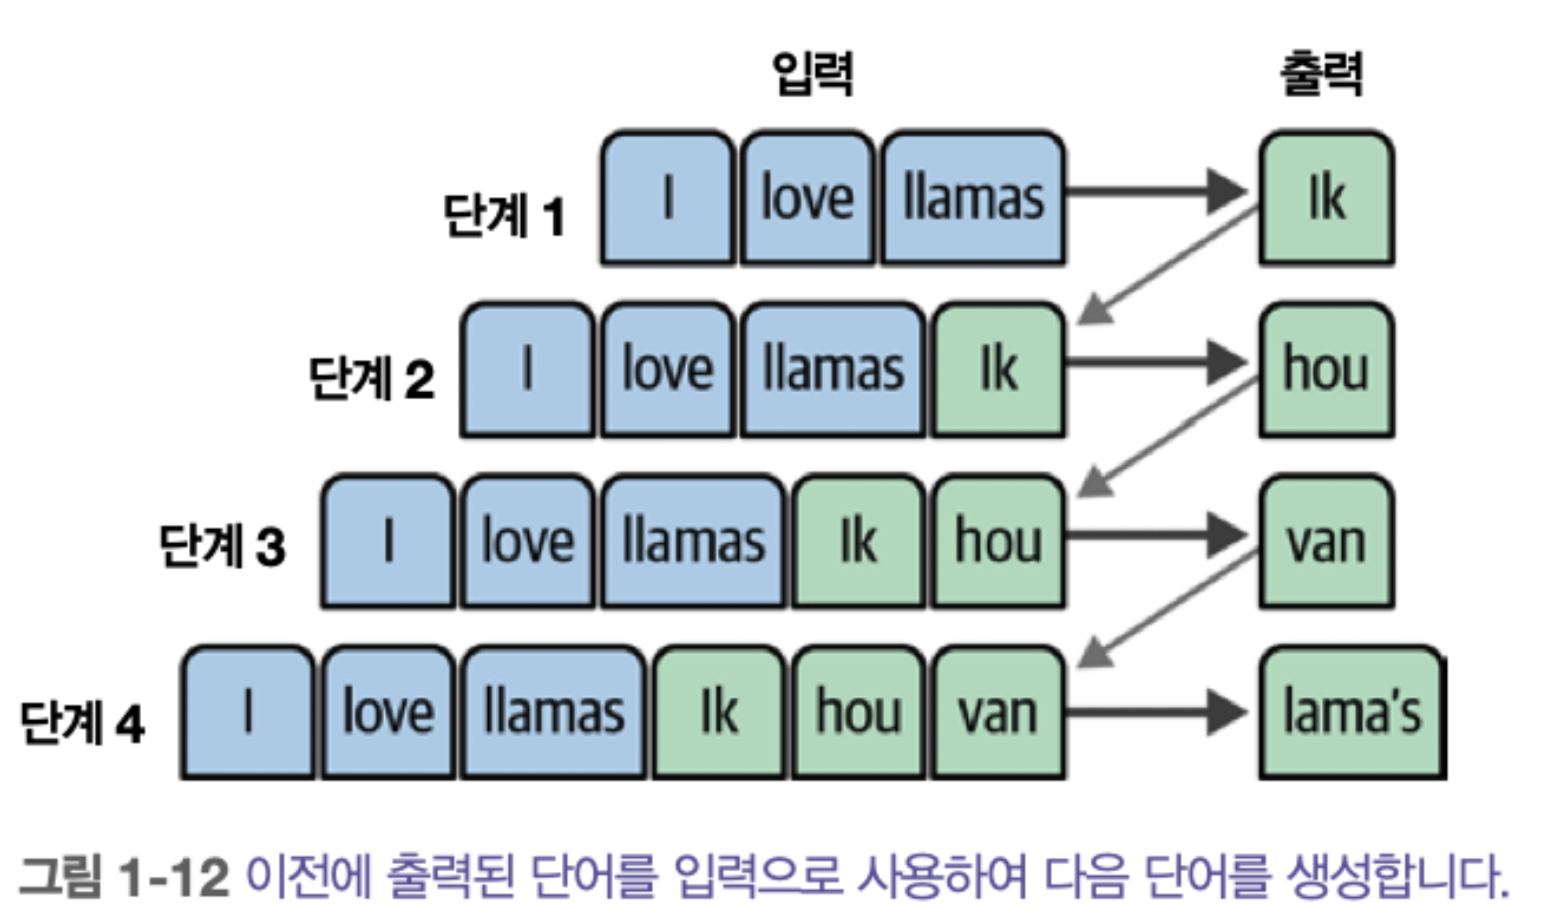
- 인코딩 단계의 목표는 입력을 가능한 잘 표현하여 디코더의 입력으로 사용되는 임베딩의 형태로 문맥을 생성하는 것. 이 표현을 생성하기 위해 단어에 대한 입력으로 임베딩을 사용. 즉 초기 표현으로 word2vec을 사용할 수 있음. 
    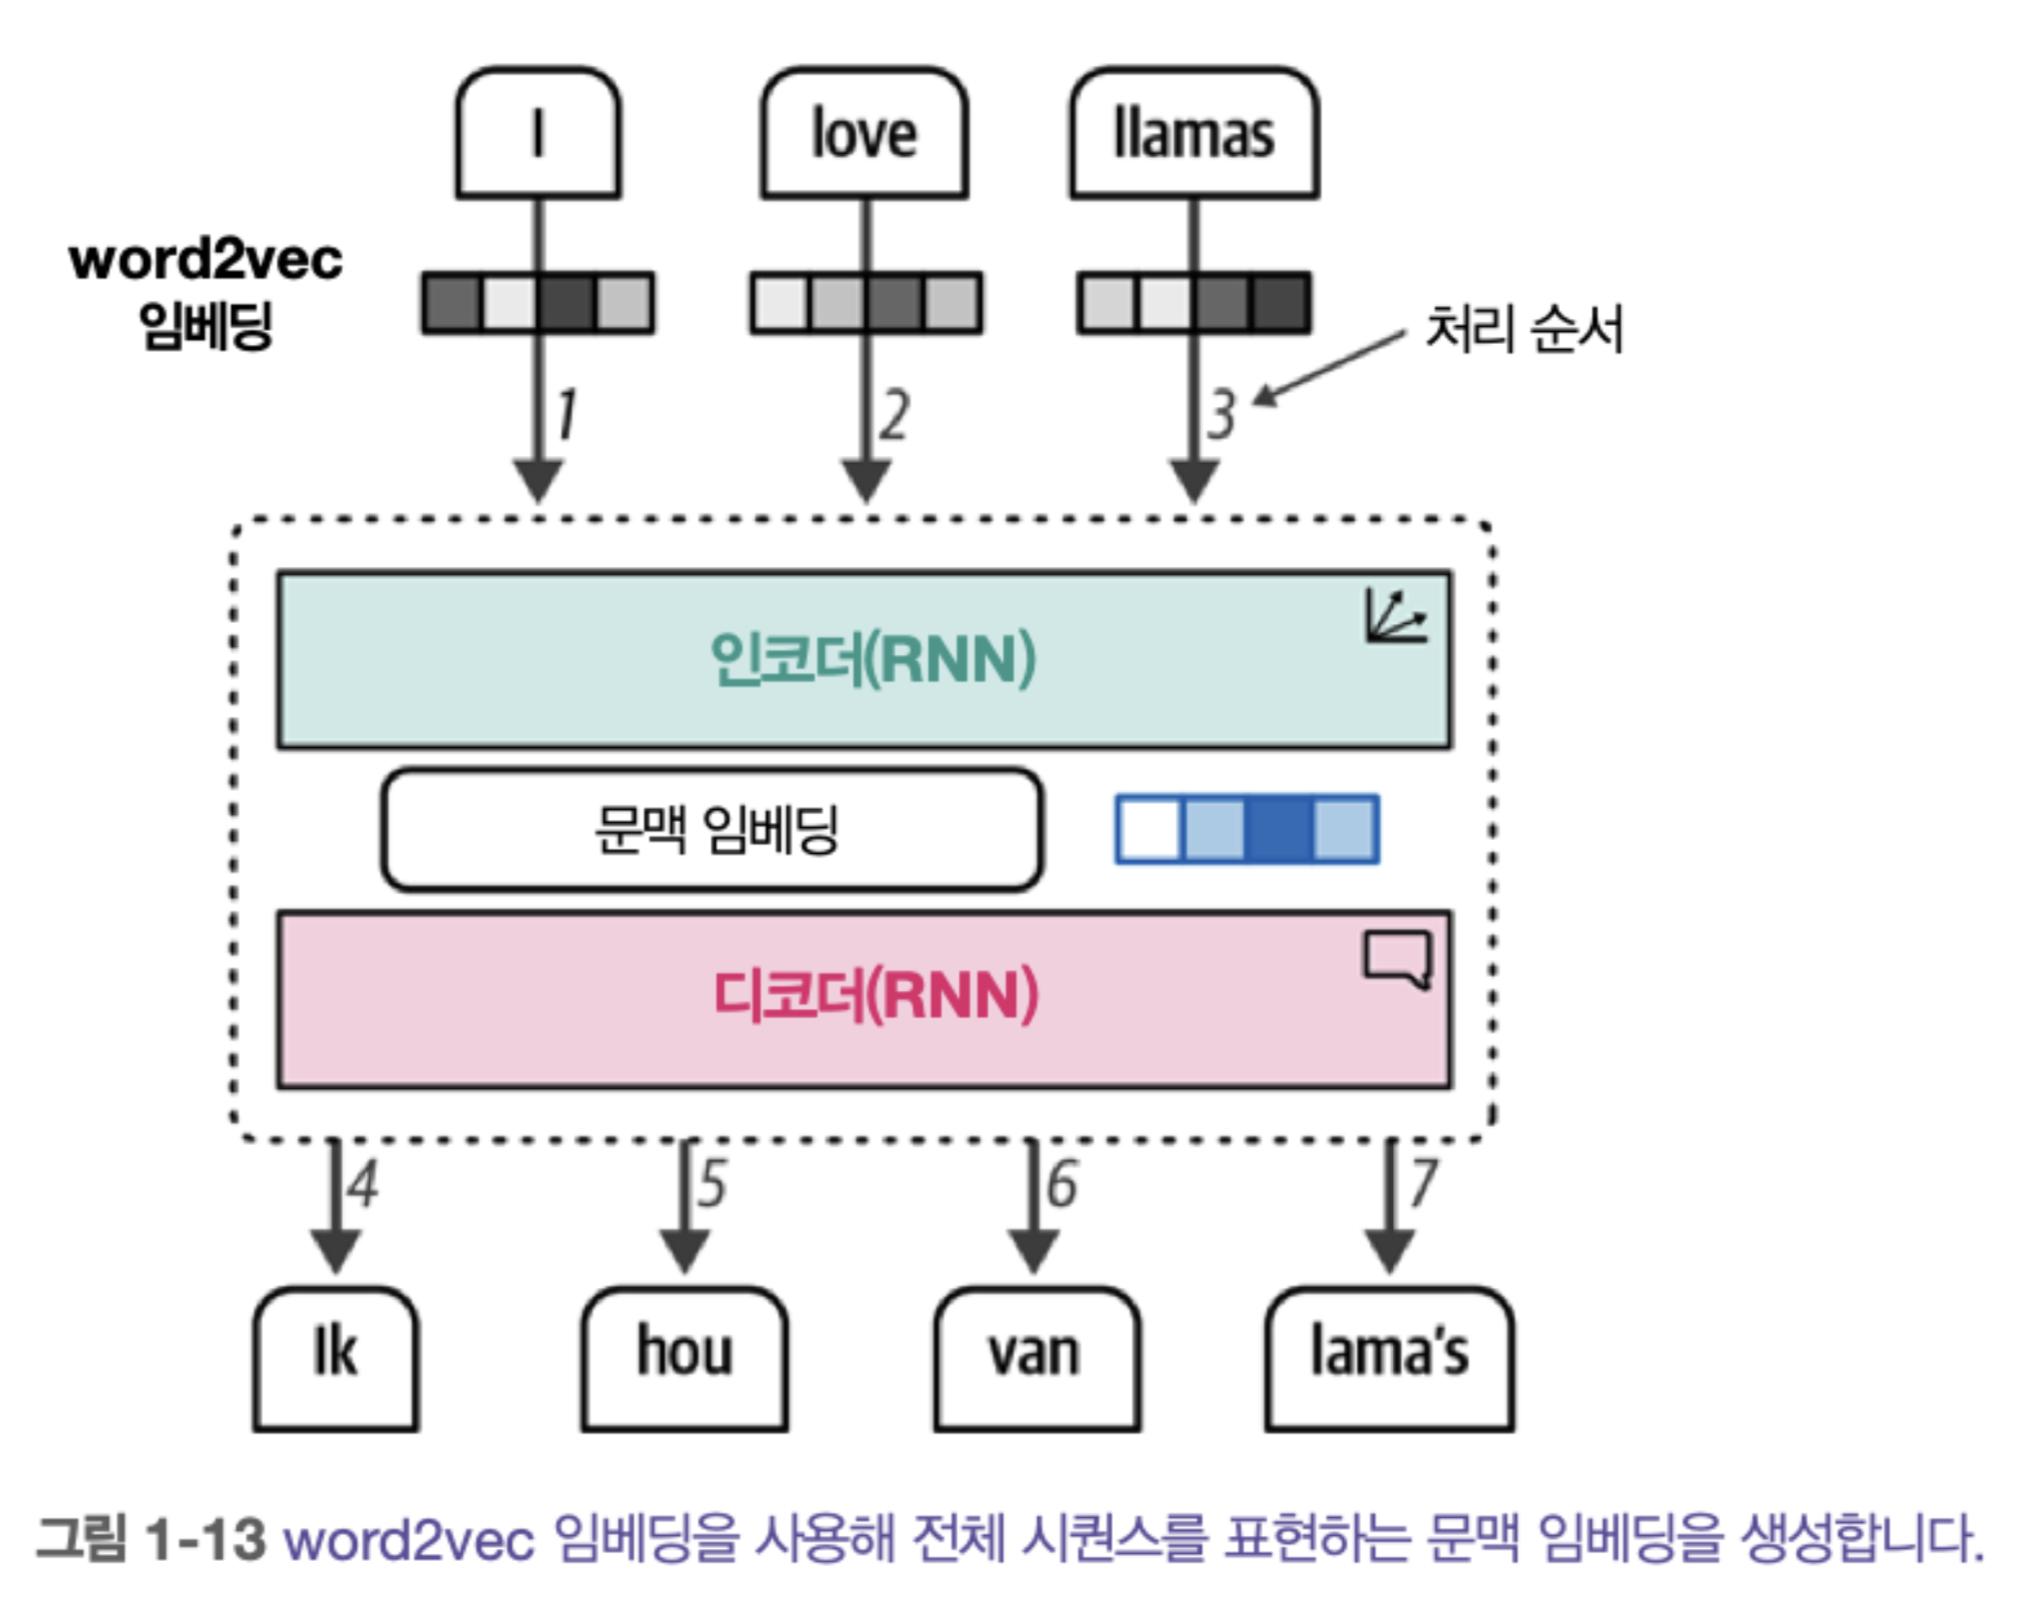
- 하지만 문맥 임베딩은 하나의 임베딩으로 전체 입력을 표현하기 때문에 긴 문장을 처리하기 어려웠고, 이 구조를 개선하기 위해 attention이라는 방법이 소개되었음: https://arxiv.org/pdf/1409.0473
    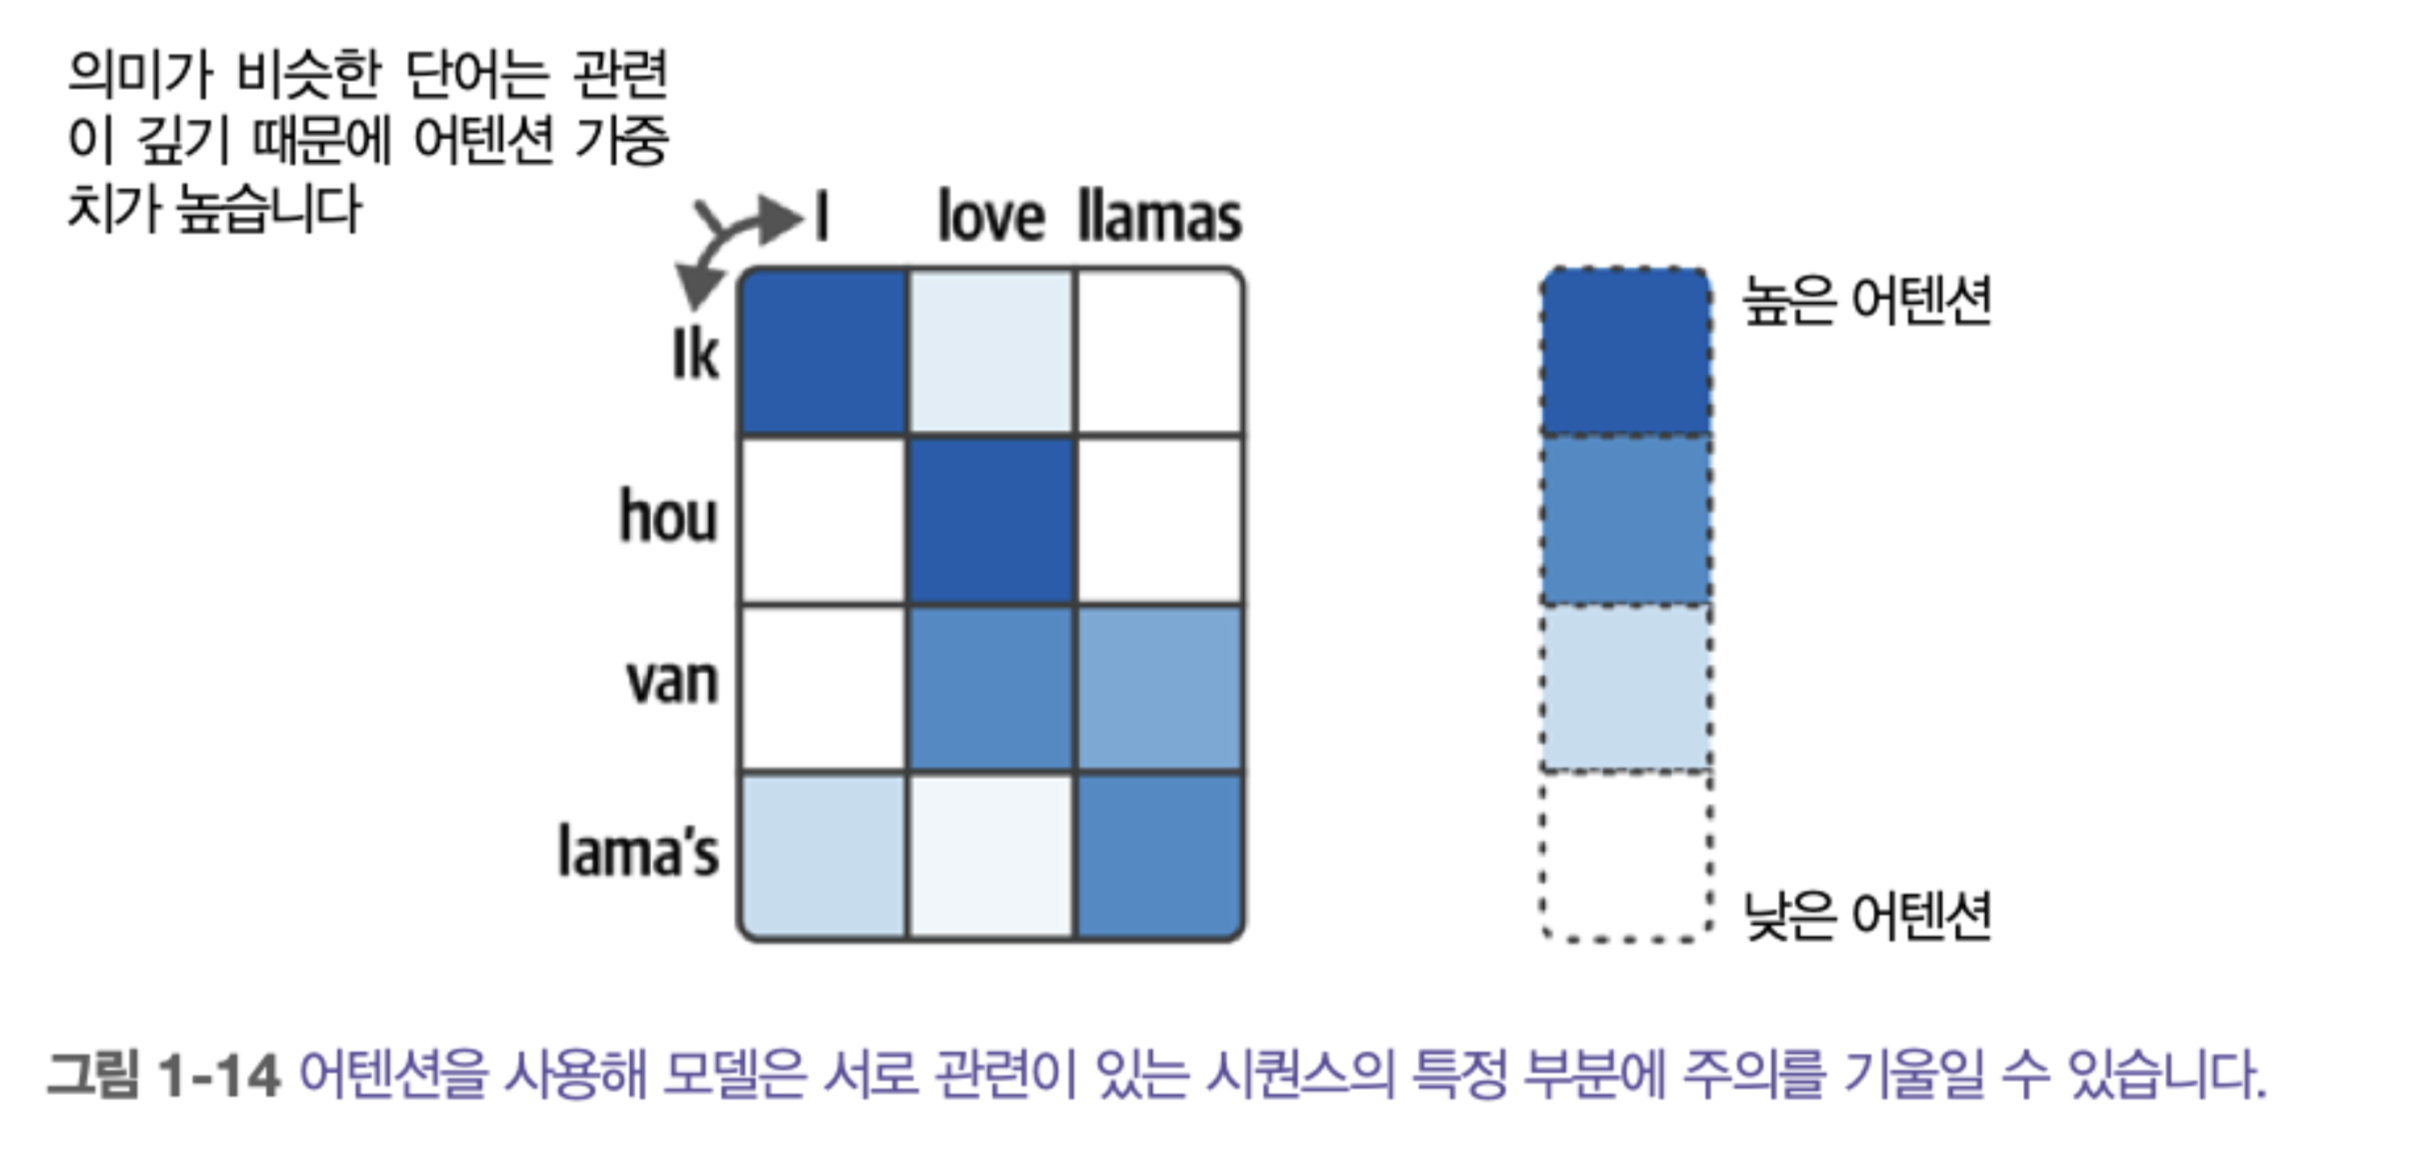
- 위 그림에 나타난 어텐션을 사용하묜 입력 시퀀스에서 서로 관련 있는 부분에 모델이 초점을 맞추고 해당 신호를 증폭할 수 있음. 어텐션은 주어진 문장에서 어떤 단어가 가장 중요한지 선택적으로 결정함. 
- 어텐션 메커니즘을 디코더 단계에 추가함으로써 RNN이 입력 시퀀스의 각 단어에 대해 출력 가능성에 관련된 신호를 생성할 수 있음. 문맥 임베딩을 디코더에 전달하는 대신 모든 입력 단어의 은닉 상태가 전달된다. 
    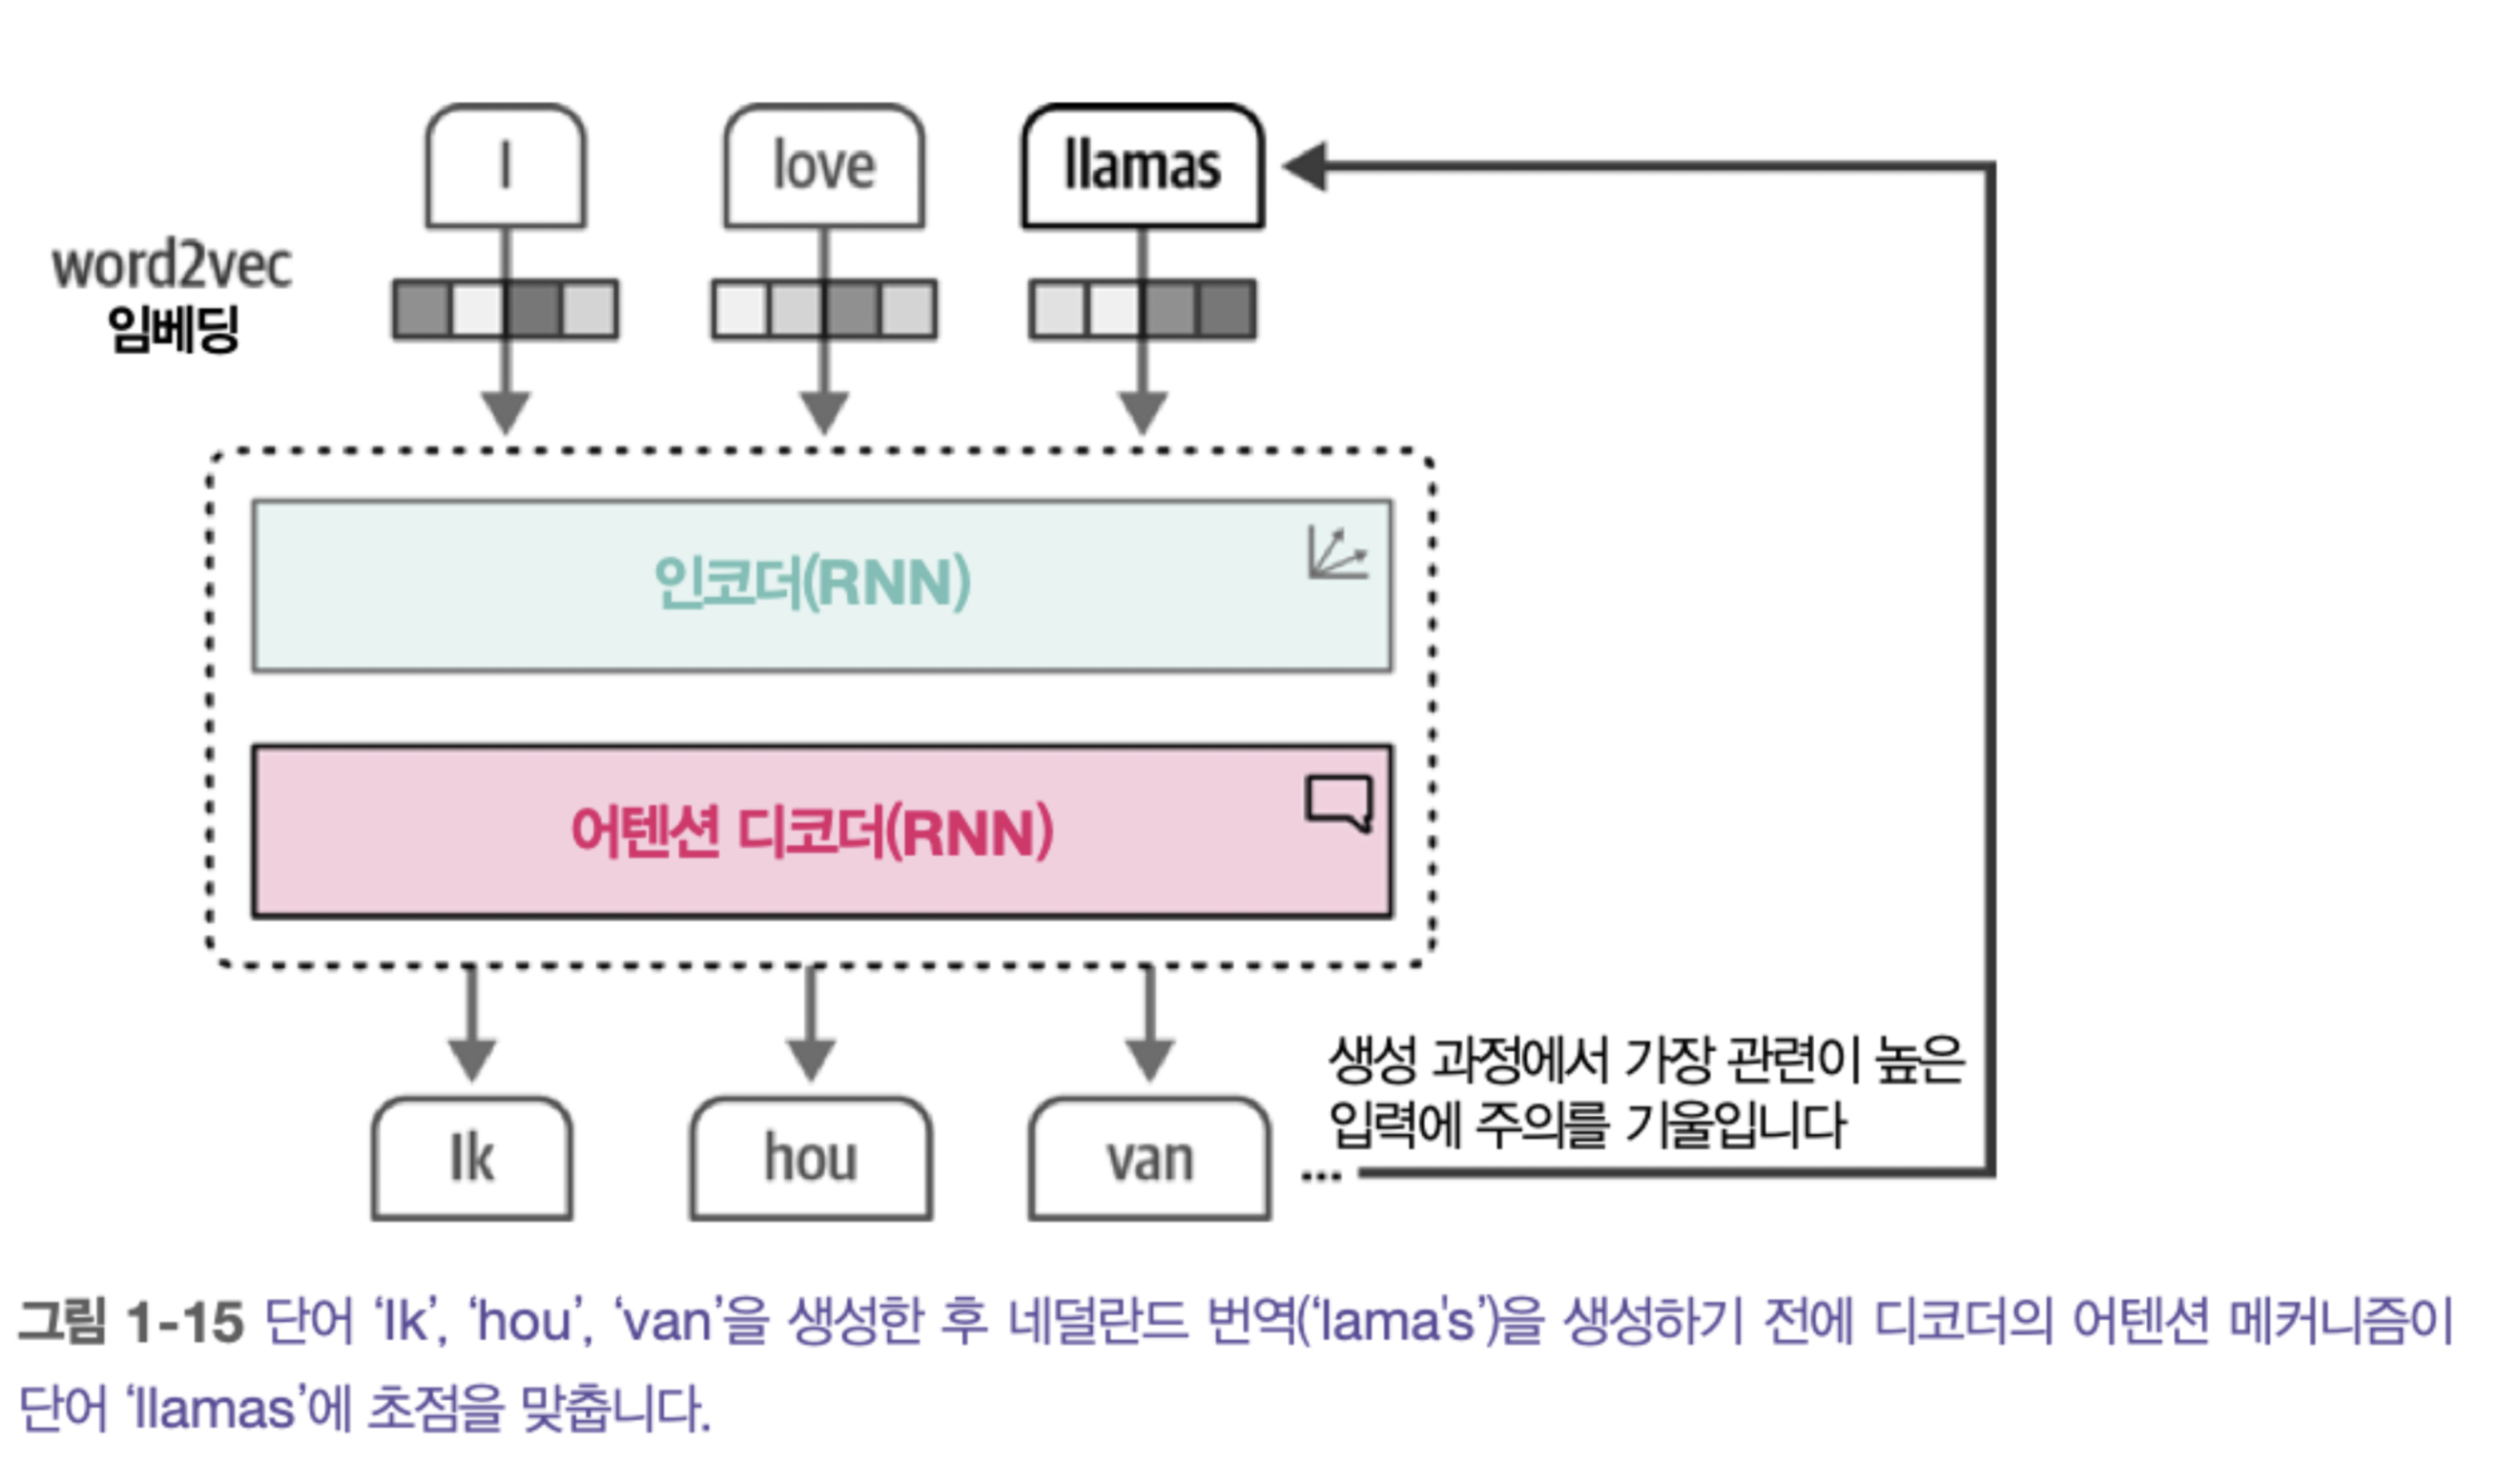
- word2vec과 위 그림의 구조를 비교하면 이 구조는 텍스트의 순차적 특징과 전체 문장에 주의를 기울임으로써 텍스트의 문맥을 표현할 수 있음. 하지만 이런 순차적 특징은 모델훈련을 병렬화하는데 방해가 된다. 

#### 1.2.5 Attention Is All You Need
- https://arxiv.org/abs/1706.03762
- 논문의 저자들은 어텐션 메커니즘만 사용하고 RNN을 제거한 transformer라는 신경망 구조를 제안
- RNN과 비교하였을 때 transformer는 병렬로 훈련할 수 있어 훈련 속도를 크게 높을 수 있음
- transformer에서 encoder/decoder는 다음과 같이 쌓여있는 형태임. 하나의 블록씩 순차적으로 실행됨. 디코더도 동일함. 트랜스포머도 autoregressive하기에 이전에 생성된 모든 단어를 사용해서 새로운 단어를 생성함. 
    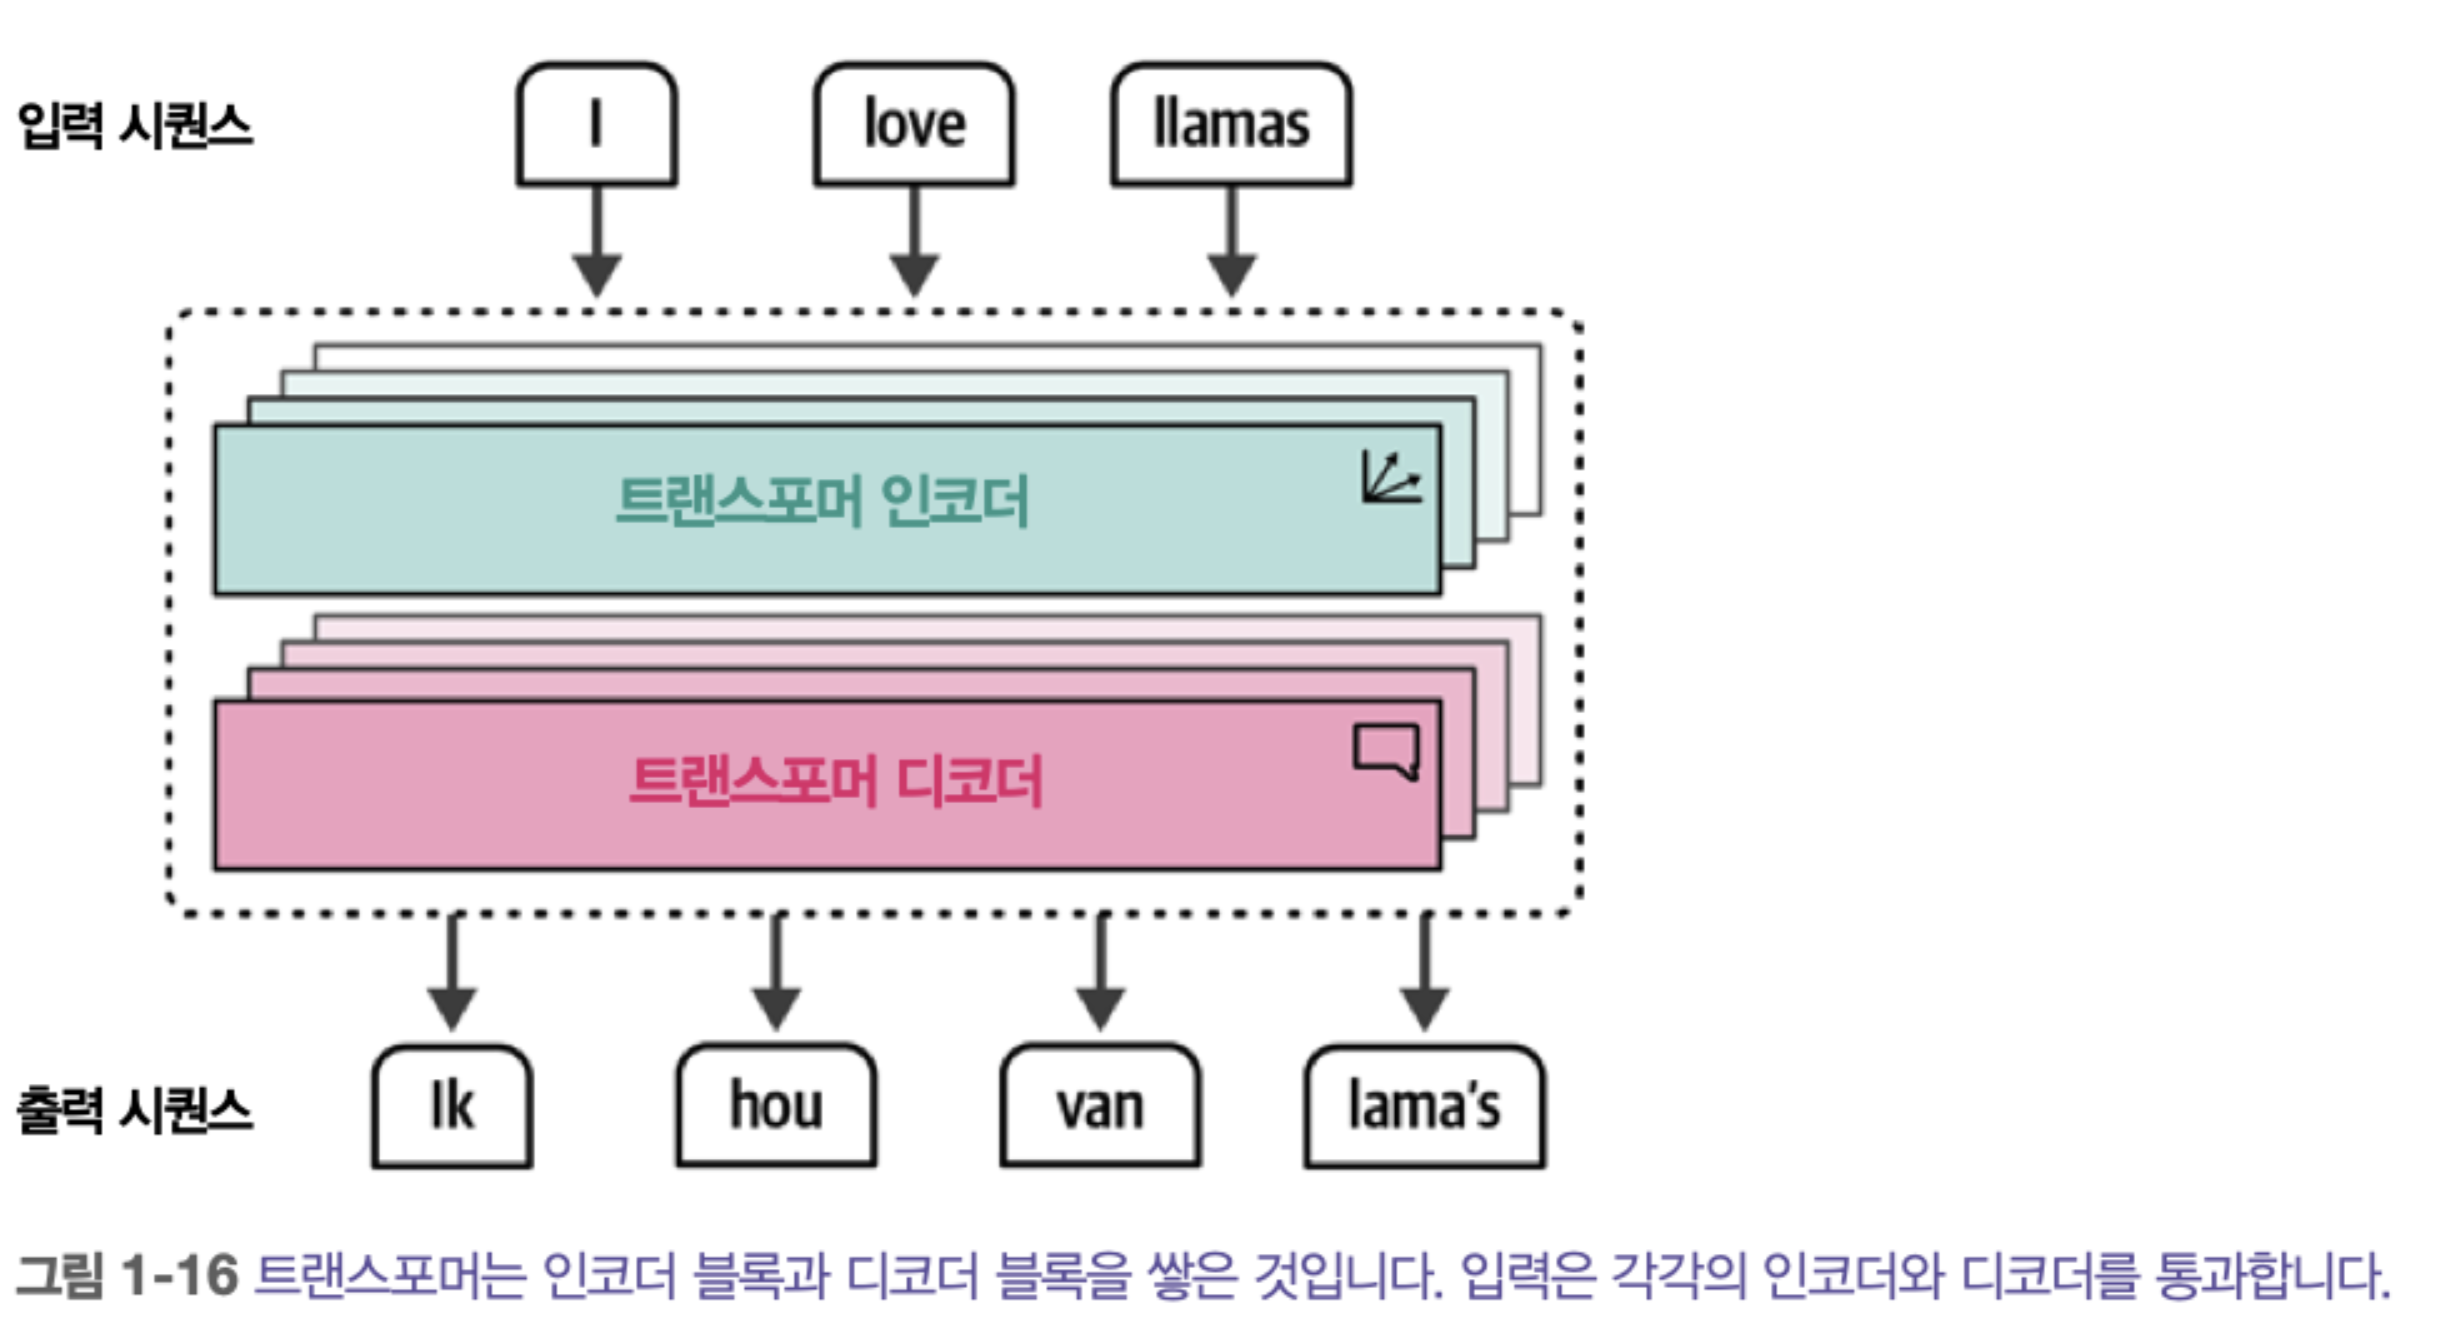
- 인코더와 디코더 블록은 어텐션 기능이 포함된 RNN을 활용하는 대신, 어텐션을 중심으로 구동된다. 트래ㄴ스포머의 인코더 블록은 아래 그림에서 보듯이 self-attention과 feed forward neural network 두 부분으로 구성됨. 
    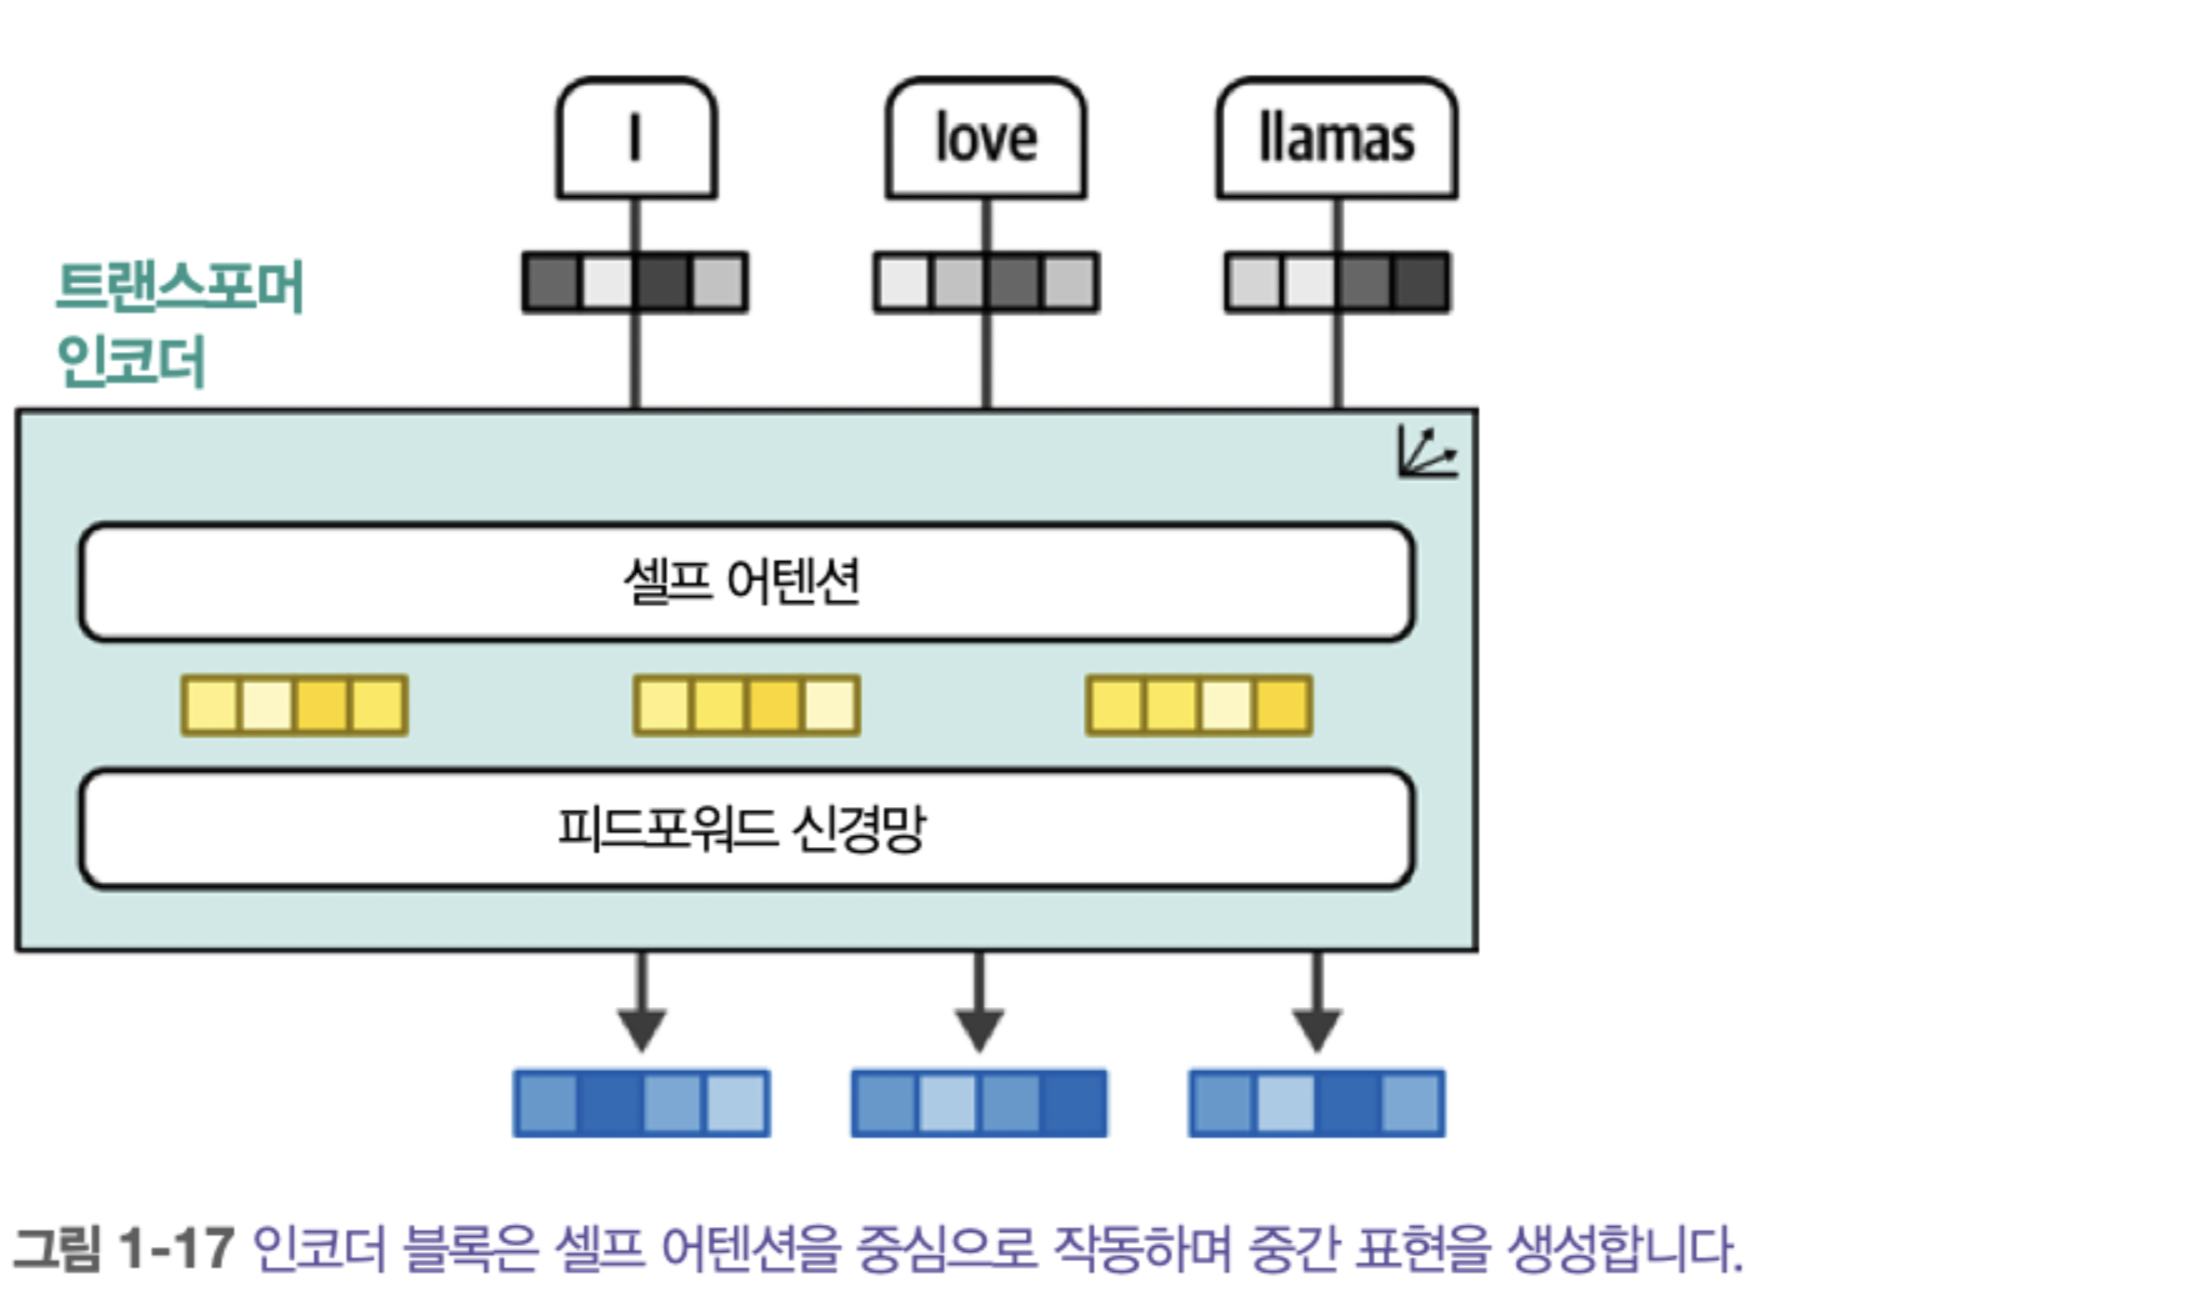
- 이전 어텐션 방법과 비교하면 셀프 어텐션은 한 시퀀스 안의 다른 위치에 주의를 기울인다. 따라서 아래 그림처럼 입력 시퀀스를 더 쉽고 정확하게 표현할 수 있다. 한 번에 하나의 토큰을 처리하지 않고 전체 시퀀스를 한 번에 처리할 수 있다. 
    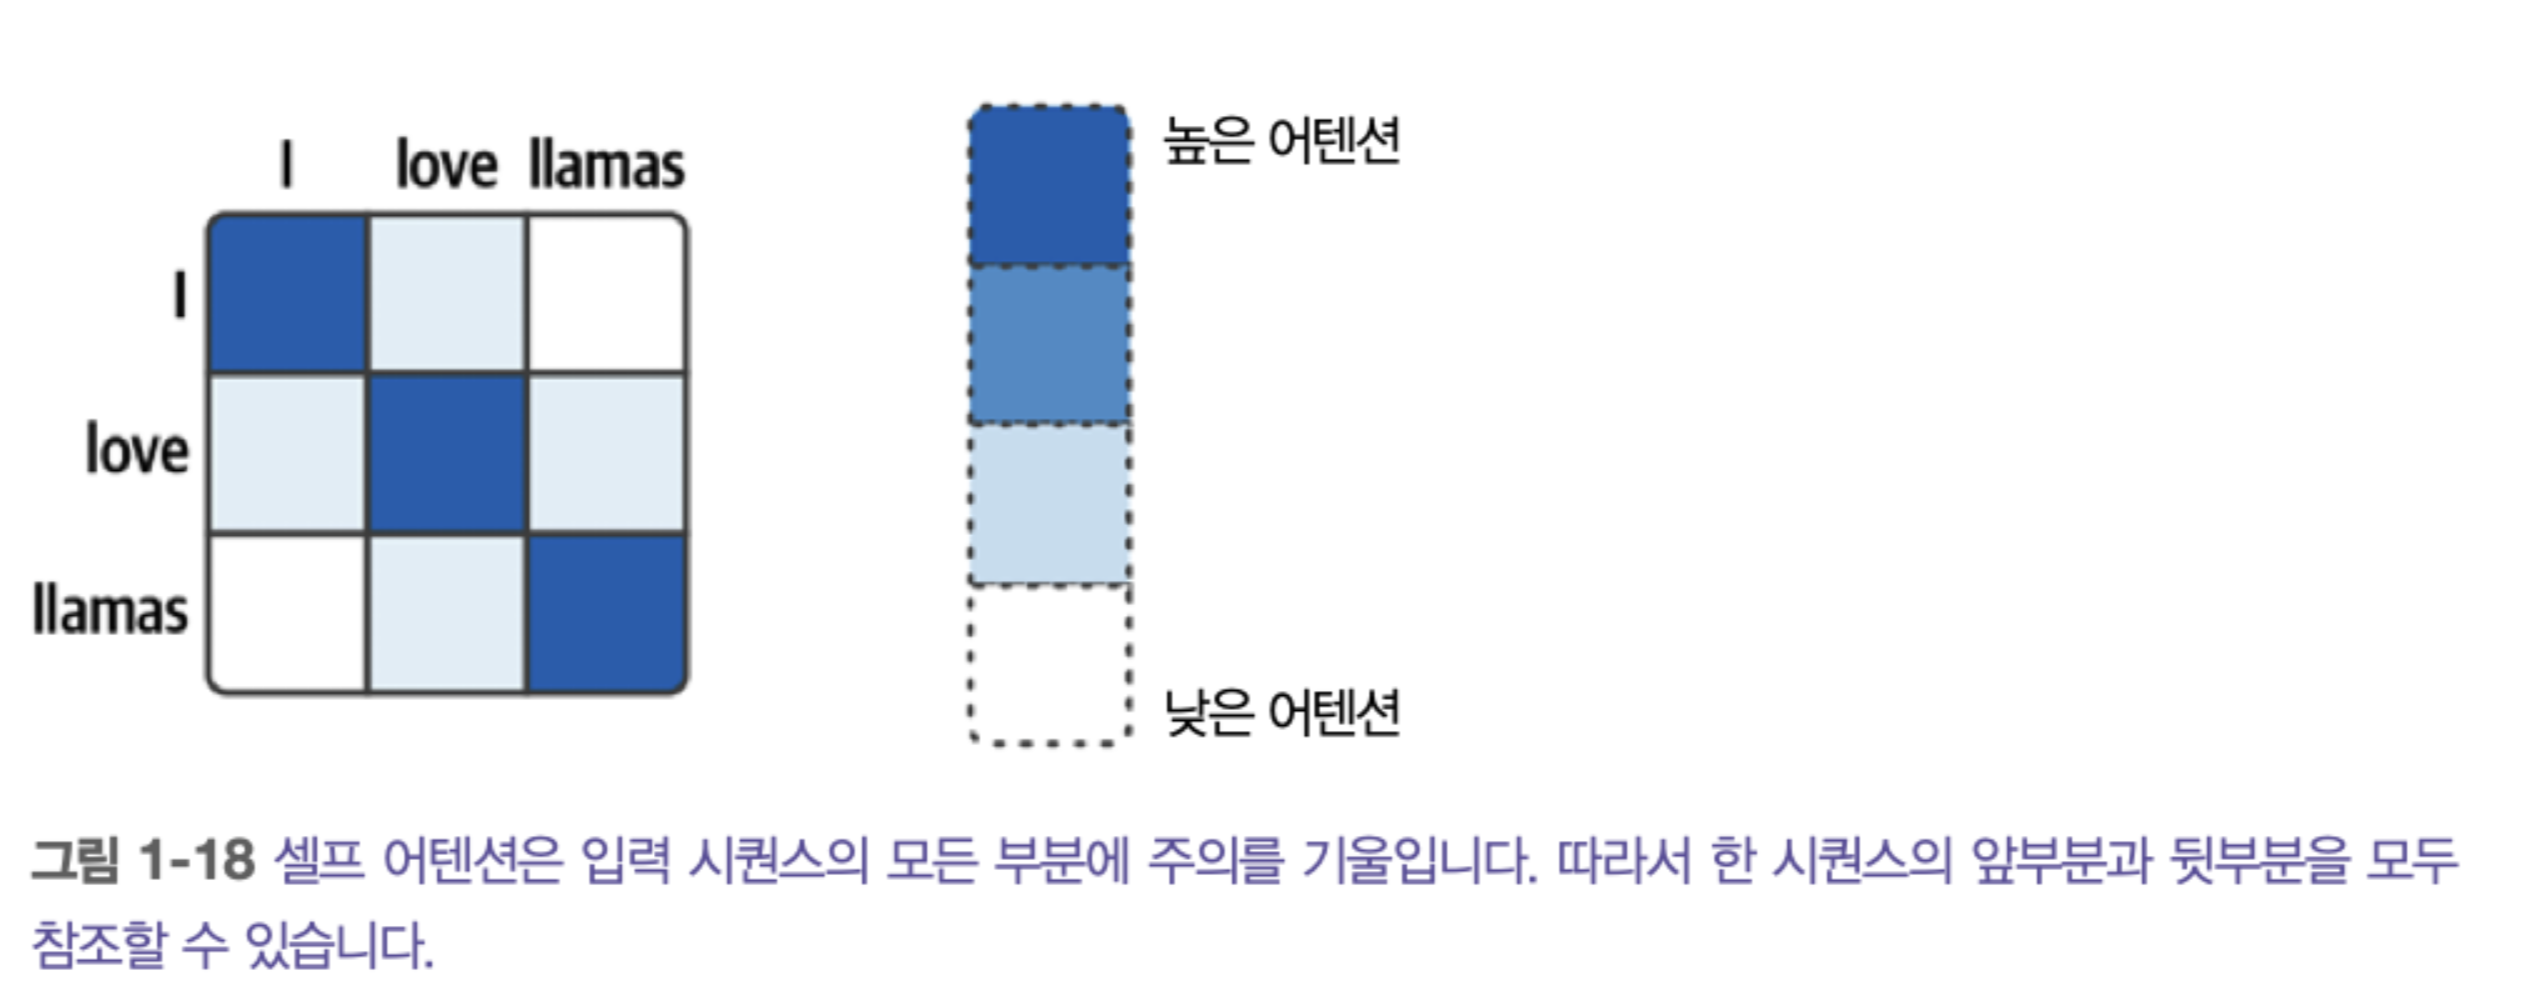
- 인코더와 달리 디코더는 인코더의 출력에 주의를 기울이는 별도의 층이 추가된다. 이 과정은 앞서 RNN 어텐션 디코더와 비슷하다. 
    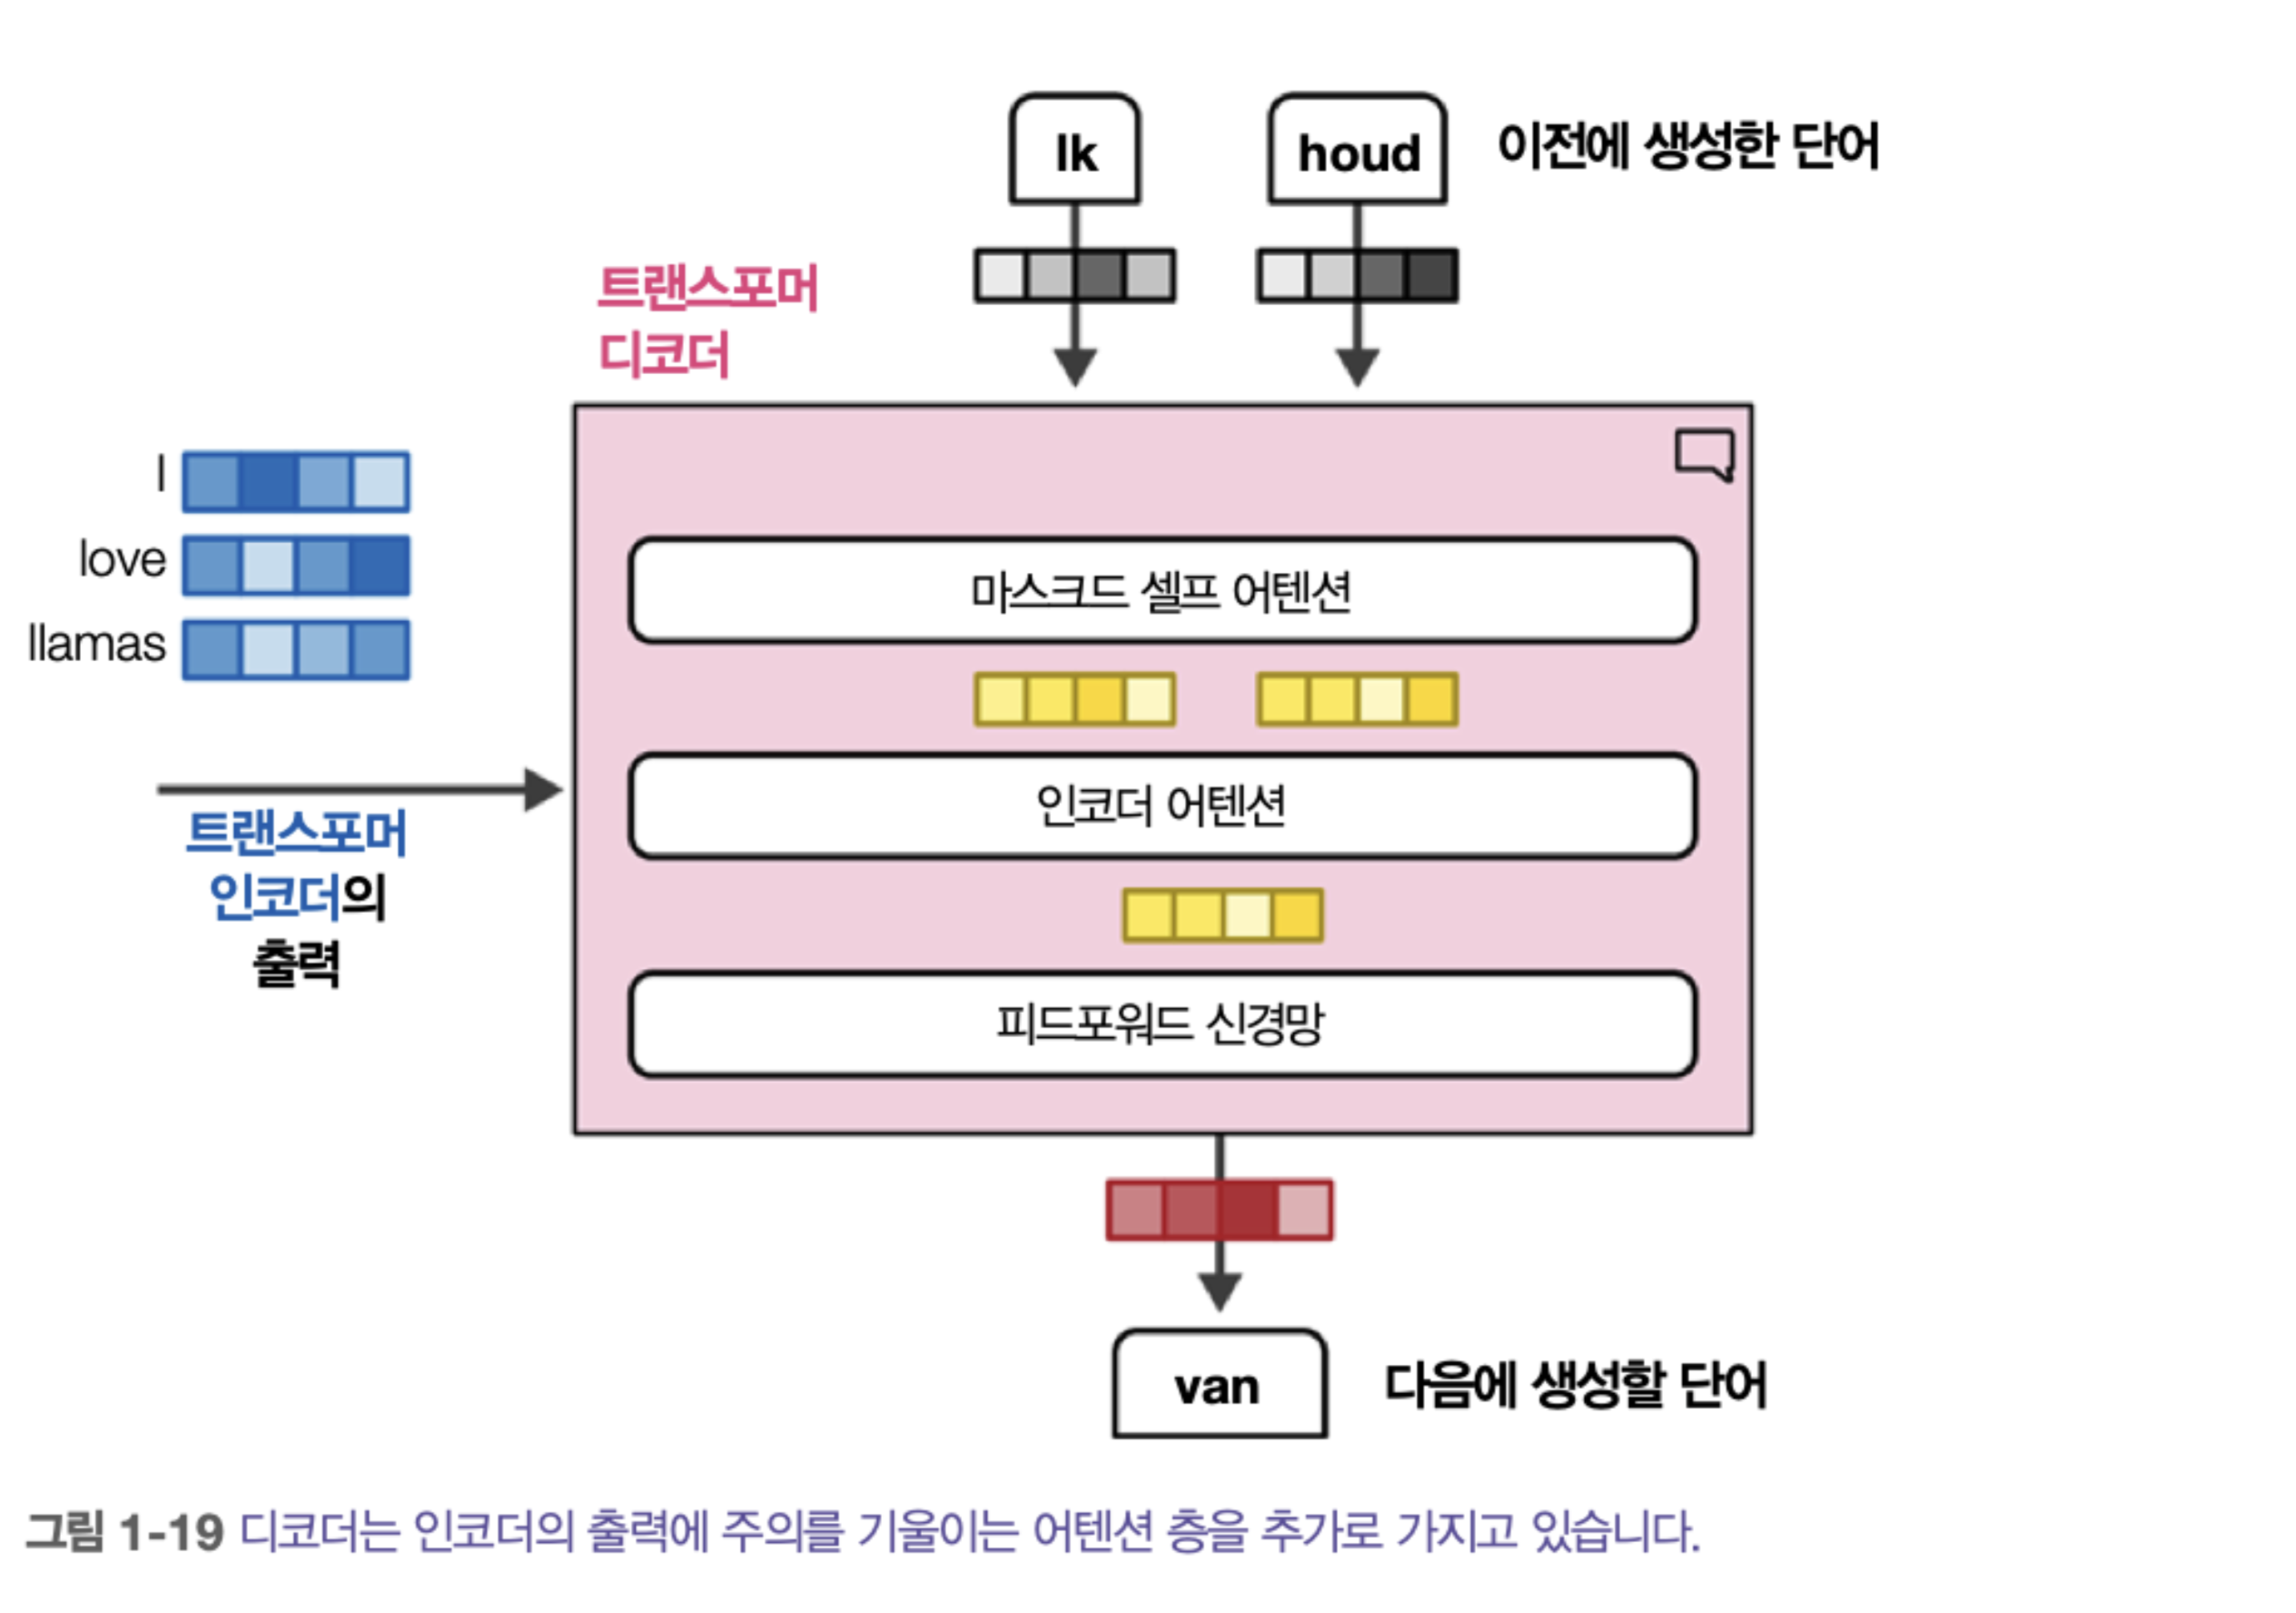
- 아래 그림에서 볼 수 있듯이 디코더의 셀프 어텐션 층은 미래의 위치를 masking한다. 이는 디코더가 autoregressive하게 동작한다고 가정하기 때문이다. 즉, 각 위치에서 다음 위치의 정보를 사용하지 않고 디코더 블록의 출력이 만들어져야 한다. 따라서 출력을 생성할 때 정보 누출을 방지하기 위해 앞선 위치에만 주의를 기울일 수 있다. 
    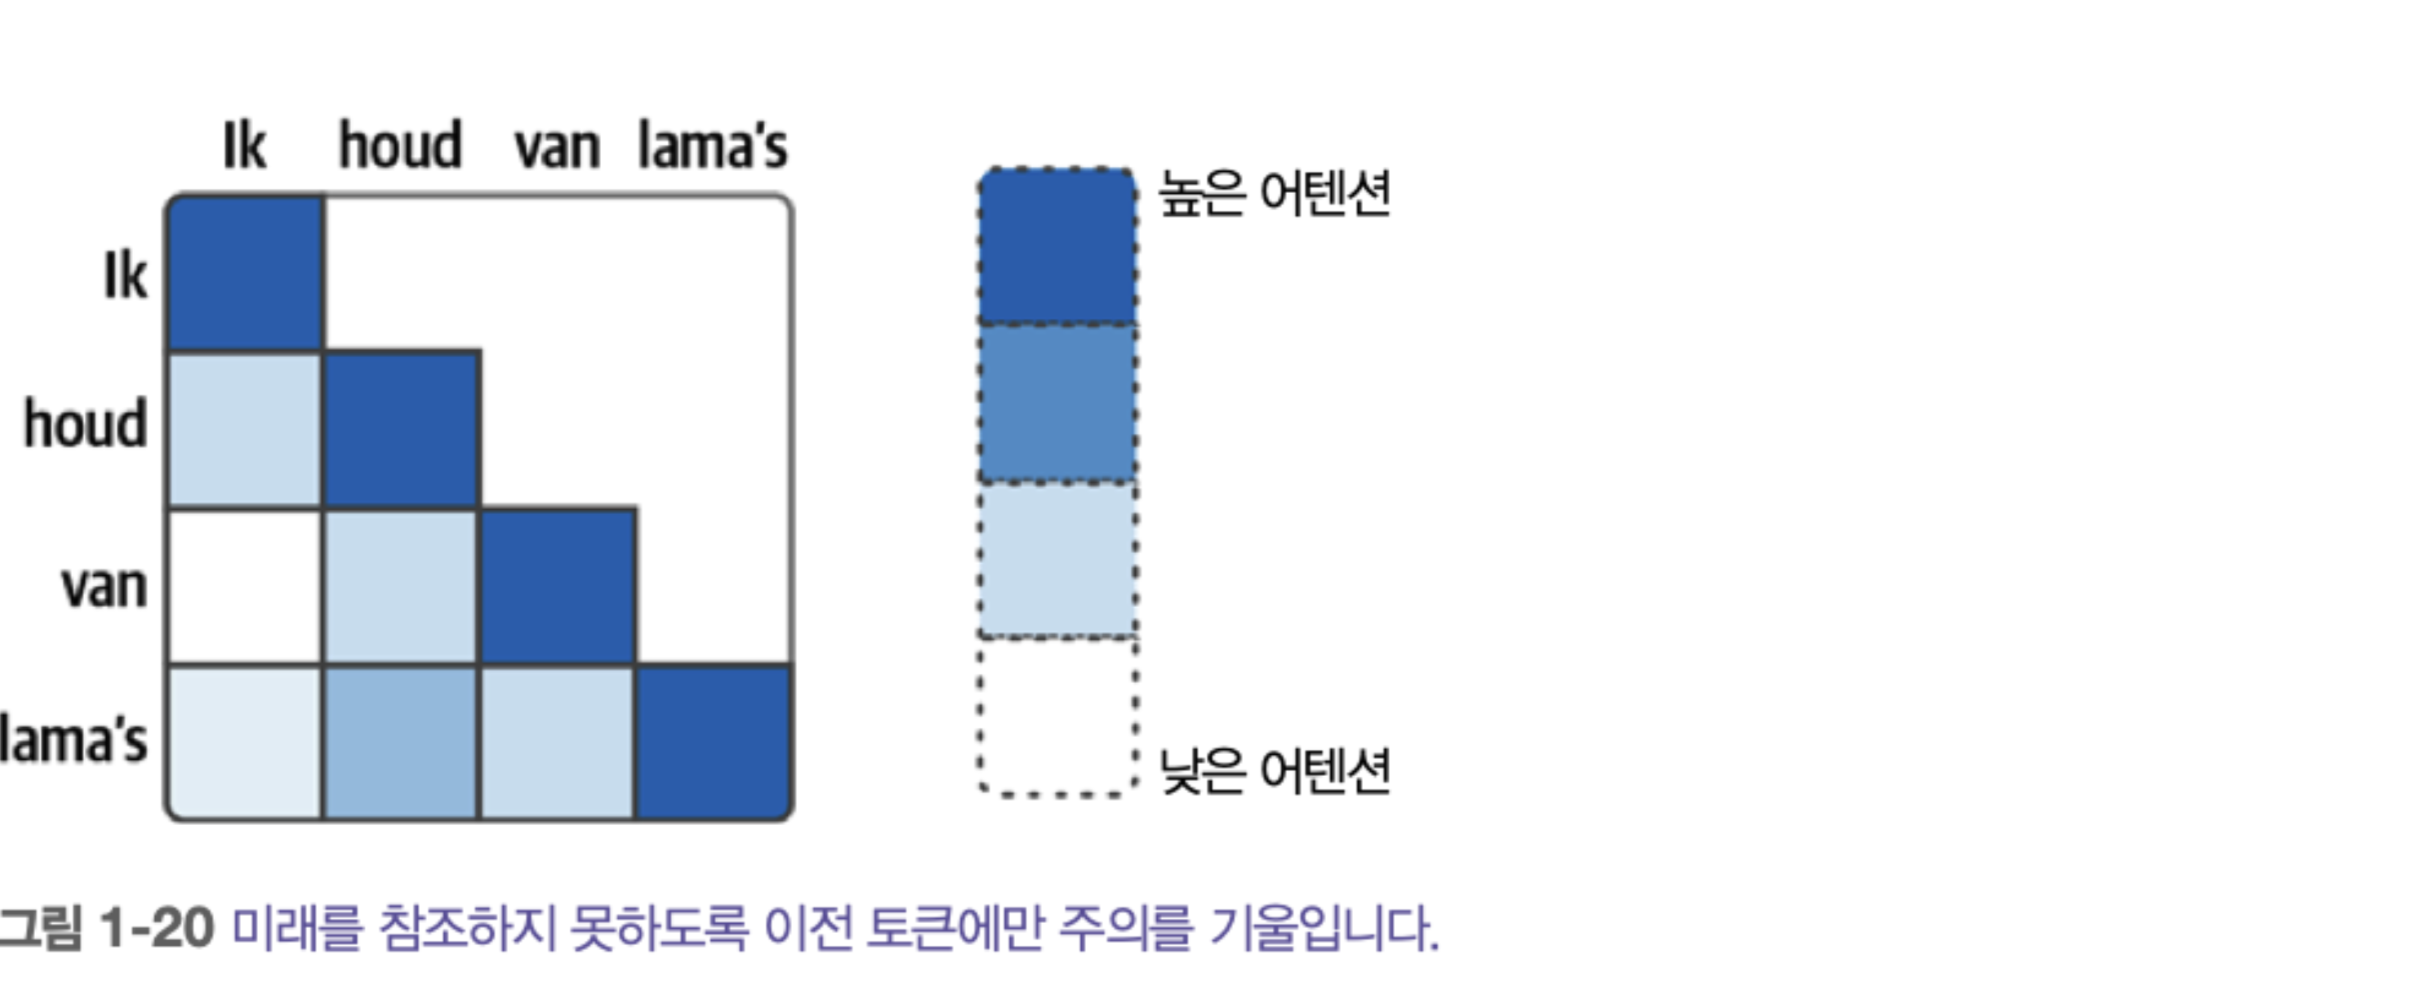